# An Autonomoues AI Scientist for Planet Scale Disaster Prediction using Multimodal Satellite and Geophysical Data Fusion
### M.Tech Project | Guide: Dr. R.S. Ponmagal | Student: Shanmugaapriyan M

---

## System Architecture
```
USGS + FIRMS + IBTrACS + Open-Meteo + SAR Satellite
                       |
        EM-DAT Ground Truth Labels (manual)
                       |
         ┌─────────────────────────────┐
         │   TABULAR SPECIALIST MODELS  │
         │  Earthquake | Wildfire       │
         │  Cyclone    | Flood          │
         │  (LightGBM + Optuna + SMOTE) │
         └─────────────────────────────┘
                       |
         ┌─────────────────────────────┐
         │  SATELLITE SEGMENTATION      │
         │  UNet (CNN Encoder-Decoder)  │
         │  SegFormer (Vision Transformer)│
         │  SAR flood pixel mapping     │
         └─────────────────────────────┘
                       |
         ┌─────────────────────────────┐
         │  FUSION LAYER               │
         │  Meta-LightGBM              │
         │  Physics-Informed Gate      │
         │  Multimodal Combiner        │
         └─────────────────────────────┘
                       |
         ┌─────────────────────────────┐
         │  AUTONOMOUS AI SCIENTIST    │
         │  Monitor → Drift → Retrain  │
         │  JSON Audit Log             │
         └─────────────────────────────┘
                       |
              Disaster Risk Prediction
```

## Dataset Status
| Dataset | Method | Notes |
|---------|--------|-------|
| USGS Earthquake | Auto | mag >= 4.5, 2010-2024 |
| NASA FIRMS Fire | Auto | Free key: firms.modaps.eosdis.nasa.gov/api/area/ |
| IBTrACS Cyclone | Auto | Full global tracks since 1980 |
| Open-Meteo Climate | Auto | 10 disaster-prone locations |
| SAR Satellite | Auto | WorldFloods / Copernicus / Synthetic fallback |
| **EM-DAT Historical** | **Manual** | **Register free at emdat.be -- required for accurate labels** |


In [ ]:
import subprocess, torch
g = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if g.returncode == 0:
    print('GPU Found!')
    for l in g.stdout.split('\n')[:12]: print(l)
else:
    print('No GPU -> Runtime -> Change runtime type -> T4 GPU')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

GPU Found!
Thu Mar 26 19:02:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------------------




## Step 2: Install Dependencies

Installs all required packages for both the tabular pipeline and the satellite deep learning module.

In [ ]:
%%capture
# Tabular ML
!pip install lightgbm xgboost scikit-learn imbalanced-learn optuna shap
!pip install pandas numpy matplotlib seaborn tqdm requests openpyxl pillow

# Deep Learning — satellite segmentation
!pip install transformers timm einops segmentation-models-pytorch
!pip install albumentations
print('All packages installed!')

## Step 3: Imports and Global Config

1.   List item
2.   List item


In [ ]:
# ── Tabular ML ────────────────────────────────────────────────
import os, re, json, warnings, requests, time, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from datetime import datetime, timedelta
from collections import deque
from tqdm.notebook import tqdm
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics         import (classification_report, f1_score,
                                     accuracy_score, roc_auc_score,
                                     jaccard_score)
from imblearn.over_sampling  import SMOTE
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# ── Deep Learning ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Drive + paths ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/DisasterAI_Final'
for d in ['data/raw','data/processed','checkpoints','results','logs']:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)
RAW_DIR  = os.path.join(BASE_DIR, 'data/raw')
PROC_DIR = os.path.join(BASE_DIR, 'data/processed')
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
RES_DIR  = os.path.join(BASE_DIR, 'results')

DISASTERS   = ['flood', 'wildfire', 'cyclone', 'earthquake', 'no_disaster']
NUM_CLASSES = len(DISASTERS)
C2I = {c: i for i, c in enumerate(DISASTERS)}
I2C = {i: c for c, i in C2I.items()}

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 256
BATCH_SIZE = 8

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.bool_):    return bool(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)

print("Config ready")
print(f"  Classes  : {DISASTERS}")
print(f"  Device   : {DEVICE}")
print(f"  Save dir : {BASE_DIR}")

Mounted at /content/drive
Config ready
  Classes  : ['flood', 'wildfire', 'cyclone', 'earthquake', 'no_disaster']
  Device   : cuda
  Save dir : /content/drive/MyDrive/DisasterAI_Final


## Step 4: Download All Datasets

Downloads all data sources in one step:

| Source | Data type | Notes |
|--------|-----------|-------|
| USGS | Seismic sensor (tabular) | mag >= 4.5, 2010-2024 |
| IBTrACS | Cyclone tracks (tabular) | Full global, since 1980 |
| Open-Meteo | Climate (tabular) | 10 disaster-prone locations |
| NASA FIRMS | Fire detections (tabular) | Add free key below |
| WorldFloods / Copernicus | SAR satellite (image) | Auto-fallback to synthetic |

> **NASA FIRMS key (free, 30 sec):** https://firms.modaps.eosdis.nasa.gov/api/area/


USGS: 112,291 records loaded
IBTrACS: 291,780 records loaded
Open-Meteo: 10,958 climate records loaded
NASA FIRMS: 50,704 fire records loaded from cache

───────────────────────────────────────────────────────
Loading WorldFloods v1.0 (Sentinel-2) from Google Drive...
───────────────────────────────────────────────────────

  Step A: Checking zip at /content/drive/MyDrive/Satellite dataset/dataset.zip ...
  Already extracted — skipping unzip

  Step B: Folder structure check:
    train   S2:   20 tifs   gt:   20 tifs
    val     S2:    6 tifs   gt:    6 tifs
    test    S2:   11 tifs   gt:   11 tifs

  Step C: Loading Sentinel-2 + mask pairs...
    train: 20 files found...
      [1/20] ✓ 01042016_Holmes_Creek_at_Vernon_FL.tif  flood=6.3%  bands=13
      [2/20] ✓ 08162016_Mississippi_River_at_Baton_Rouge_  flood=2.8%  bands=13
      [3/20] ✓ EMSR257_01MANDRA_GRA_v2_observed_event_a.t  flood=14.0%  bands=13
      [4/20] ✓ EMSR258_03KOLONJE_DEL_v2_observed_event_a.  flood=1.2%  bands=13
 

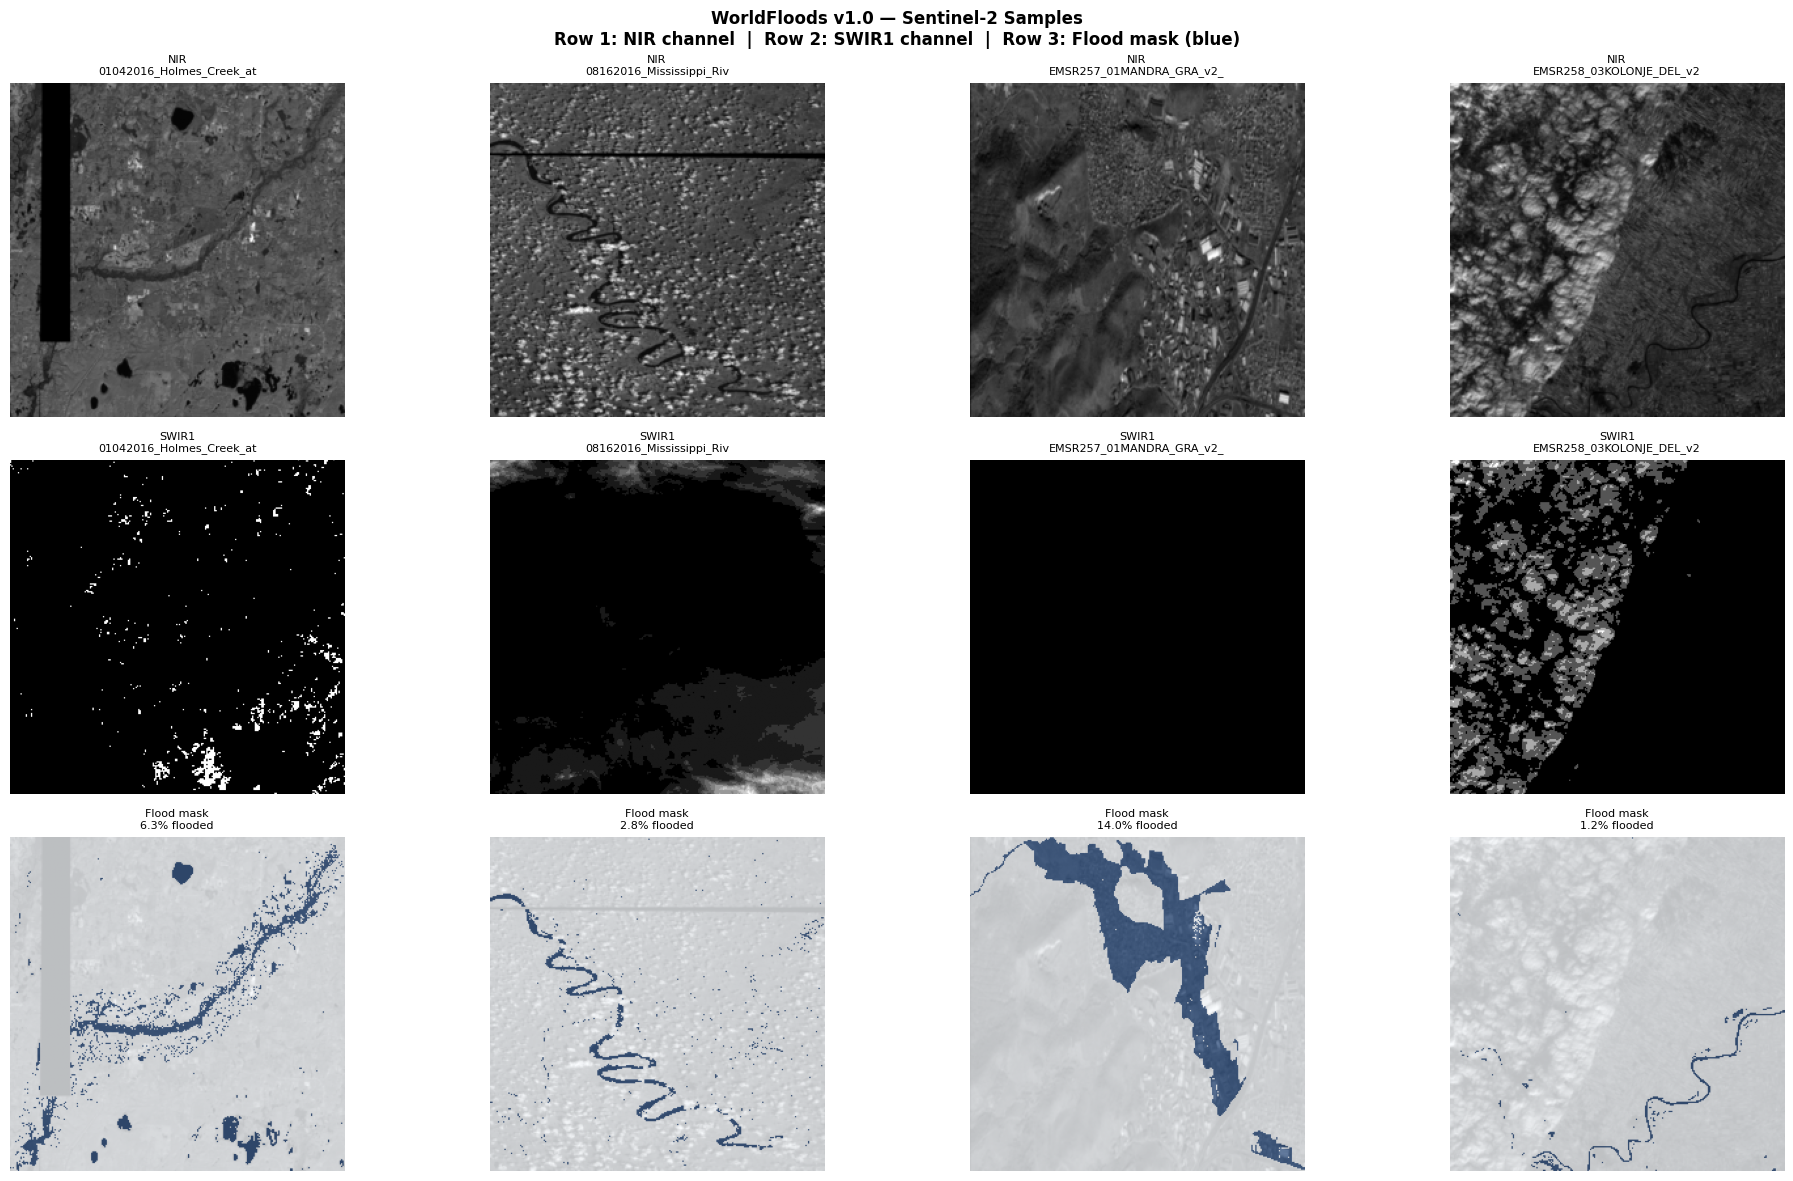

  Sample plot saved -> /content/drive/MyDrive/DisasterAI_Final/results/worldfloods_s2_samples.png
  ✅ WorldFloods Sentinel-2 loaded successfully!

All datasets ready:
  USGS Earthquakes : 112,291 records
  IBTrACS Cyclones : 291,780 records
  Open-Meteo       : 10,958 records
  NASA FIRMS       : 50,704 records
  Satellite        : 37 samples  [source: WorldFloods_v1.0_S2]


In [ ]:
# ===== USER CONFIG =====
FIRMS_MAP_KEY   = "Use your API"
WORLDFLOODS_ZIP = '/content/drive/MyDrive/Satellite dataset/dataset.zip'
# =======================

def safe_get(url, params=None, timeout=60):
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r
    except Exception as e:
        print(f"  Request failed: {e}")
        return None

# ── 1. USGS Earthquakes ────────────────────────────────────────
usgs_path = f'{RAW_DIR}/usgs_earthquakes.csv'
if not os.path.exists(usgs_path):
    print("Downloading USGS Earthquakes (2010-2024, mag >= 4.5)...")
    records = []
    for yr in range(2010, 2025):
        r = safe_get('https://earthquake.usgs.gov/fdsnws/event/1/query',
                     params=dict(format='geojson', starttime=f'{yr}-01-01',
                                 endtime=f'{yr}-12-31', minmagnitude=4.5))
        if r:
            for f in r.json().get('features', []):
                p, c = f['properties'], f['geometry']['coordinates']
                records.append({'time': p.get('time'), 'magnitude': p.get('mag'),
                                'depth_km': c[2] if len(c)>2 else 0,
                                'longitude': c[0], 'latitude': c[1],
                                'sig': p.get('sig',0), 'tsunami': p.get('tsunami',0),
                                'place': p.get('place','')})
    df_q = pd.DataFrame(records)
    df_q['time'] = pd.to_datetime(df_q['time'], unit='ms', utc=True)
    df_q.to_csv(usgs_path, index=False)
    print(f"  {len(df_q):,} earthquake records saved")
else:
    df_q = pd.read_csv(usgs_path, parse_dates=['time'])
    print(f"USGS: {len(df_q):,} records loaded")

# ── 2. IBTrACS Cyclone Tracks ──────────────────────────────────
ibtracs_path = f'{RAW_DIR}/ibtracs.csv'
if not os.path.exists(ibtracs_path):
    print("\nDownloading IBTrACS Cyclone data...")
    url = ('https://www.ncei.noaa.gov/data/international-best-track-archive-'
           'for-climate-stewardship-ibtracs/v04r00/access/csv/'
           'ibtracs.since1980.list.v04r00.csv')
    r = safe_get(url, timeout=120)
    if r:
        with open(ibtracs_path, 'wb') as f: f.write(r.content)
        df_cyc = pd.read_csv(ibtracs_path, skiprows=[1], low_memory=False)
        print(f"  {len(df_cyc):,} cyclone records saved")
    else:
        df_cyc = pd.DataFrame()
else:
    df_cyc = pd.read_csv(ibtracs_path, skiprows=[1], low_memory=False)
    print(f"IBTrACS: {len(df_cyc):,} records loaded")

# ── 3. Open-Meteo Climate ──────────────────────────────────────
climate_path = f'{RAW_DIR}/openmeteo_climate.csv'
LOCATIONS = [
    ('India',20.59,78.96), ('USA_South',30.00,-90.00),
    ('Philippines',13.00,122.00), ('Bangladesh',23.68,90.35),
    ('Australia',-25.27,133.77), ('Brazil',-8.00,-55.00),
    ('Indonesia',-0.78,113.92), ('Japan',36.20,138.25),
    ('Mexico',23.63,-102.55), ('Nigeria',9.08,8.67),
]
if not os.path.exists(climate_path):
    print("\nDownloading Open-Meteo climate data...")
    all_climate = []
    for name, lat, lon in LOCATIONS:
        r = safe_get('https://archive-api.open-meteo.com/v1/archive', params=dict(
            latitude=lat, longitude=lon, start_date='2010-01-01', end_date='2024-12-31',
            daily='temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,'
                  'et0_fao_evapotranspiration,weathercode,rain_sum,snowfall_sum',
            timezone='UTC'))
        if r:
            d = r.json().get('daily', {})
            df_loc = pd.DataFrame(d)
            df_loc['location'] = name
            df_loc['latitude']  = lat
            df_loc['longitude'] = lon
            all_climate.append(df_loc)
    if all_climate:
        df_clim = pd.concat(all_climate, ignore_index=True)
        df_clim.to_csv(climate_path, index=False)
        print(f"  {len(df_clim):,} climate records from {len(LOCATIONS)} locations")
    else:
        df_clim = pd.DataFrame()
else:
    df_clim = pd.read_csv(climate_path)
    print(f"Open-Meteo: {len(df_clim):,} climate records loaded")

# ── 4. NASA FIRMS Fire ─────────────────────────────────────────
firms_path = f'{RAW_DIR}/nasa_firms_fire.csv'
if not os.path.exists(firms_path):
    print("\nDownloading NASA FIRMS fire data...")
    urls_to_try = [
        # Primary: your key on VIIRS SNPP NRT
        f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{FIRMS_MAP_KEY}/VIIRS_SNPP_NRT/-180,-90,180,90/10',
        # Fallback 1: VIIRS NOAA-20 (same key, different satellite)
        f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{FIRMS_MAP_KEY}/VIIRS_NOAA20_NRT/-180,-90,180,90/10',
        # Fallback 2: MODIS NRT (same key)
        f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{FIRMS_MAP_KEY}/MODIS_NRT/-180,-90,180,90/10',
        # Fallback 3: free public MODIS 7-day (no key needed, always works)
        'https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_7d.csv',
    ]
    df_fire = pd.DataFrame()
    for attempt_url in urls_to_try:
        print(f"  Trying: {attempt_url[:72]}...")
        r = safe_get(attempt_url, timeout=120)
        if r and len(r.content) > 500:
            try:
                with open(firms_path, 'wb') as f: f.write(r.content)
                df_fire = pd.read_csv(firms_path)
                if len(df_fire) > 10:
                    print(f"  ✅ {len(df_fire):,} fire records saved")
                    break
                else:
                    print(f"  Too few records ({len(df_fire)}) — trying next URL...")
                    df_fire = pd.DataFrame()
            except Exception as e:
                print(f"  Parse error: {e} — trying next URL...")
                df_fire = pd.DataFrame()
        else:
            print(f"  No data returned — trying next URL...")
    if df_fire.empty:
        print("  ⚠️  All FIRMS URLs failed.")
        print("  Wildfire specialist will use previously cached data if available.")
        print("  Your trained wildfire model is unaffected — it used the original CSV.")
else:
    df_fire = pd.read_csv(firms_path)
    print(f"NASA FIRMS: {len(df_fire):,} fire records loaded from cache")

# ── 5. WorldFloods v1.0 — Sentinel-2 Optical ──────────────────
print("\n" + "─"*55)
print("Loading WorldFloods v1.0 (Sentinel-2) from Google Drive...")
print("─"*55)

!pip install rasterio pillow -q

import rasterio
import zipfile
import glob
from pathlib import Path
from PIL import Image as PILImage

SAT_DIR    = os.path.join(RAW_DIR, 'satellite')
WF_EXTRACT = os.path.join(SAT_DIR, 'worldfloods')
BASE_WF    = os.path.join(WF_EXTRACT, 'worldfloods_v1_0_sample')
os.makedirs(WF_EXTRACT, exist_ok=True)

df_satellite = None

# ── Step A: Extract zip ────────────────────────────────────────
print(f"\n  Step A: Checking zip at {WORLDFLOODS_ZIP} ...")
if not os.path.exists(WORLDFLOODS_ZIP):
    print(f"  ERROR: zip not found at {WORLDFLOODS_ZIP}")
else:
    already_done = os.path.exists(BASE_WF) and len(
        glob.glob(f'{BASE_WF}/**/S2/*.tif', recursive=True)) > 0
    if already_done:
        print("  Already extracted — skipping unzip")
    else:
        print("  Extracting...")
        with zipfile.ZipFile(WORLDFLOODS_ZIP, 'r') as z:
            z.extractall(WF_EXTRACT)
        print(f"  Extracted to: {WF_EXTRACT}")

    # ── Step B: Confirm structure ──────────────────────────────
    print(f"\n  Step B: Folder structure check:")
    for split in ['train', 'val', 'test']:
        s2_count = len(glob.glob(f'{BASE_WF}/{split}/S2/*.tif'))
        gt_count = len(glob.glob(f'{BASE_WF}/{split}/gt/*.tif'))
        print(f"    {split:<6}  S2: {s2_count:>4} tifs   gt: {gt_count:>4} tifs")

    # ── Step C: Load S2 + gt pairs ────────────────────────────
    def load_wf_s2_pair(s2_path, gt_path, target_size=256):
        """
        WorldFloods v1.0 Sentinel-2:
          S2 tif  — 13 bands, reflectance stored as int * 10000
                    Band 8  = NIR   (rasterio index 8, 1-based)
                    Band 11 = SWIR1 (rasterio index 11, 1-based)
          gt tif  — uint8: 0=invalid  1=land  2=flood  3=cloud
        Reads ONLY 2 bands — prevents memory crash on large tifs.
        """
        with rasterio.open(s2_path) as src:
            n_bands = src.count
            if n_bands >= 11:
                ch0 = src.read(8).astype(np.float32)    # NIR
                ch1 = src.read(11).astype(np.float32)   # SWIR1
            elif n_bands >= 4:
                ch0 = src.read(4).astype(np.float32)
                ch1 = src.read(3).astype(np.float32)
            else:
                ch0 = src.read(1).astype(np.float32)
                ch1 = src.read(min(2, n_bands)).astype(np.float32)

        with rasterio.open(gt_path) as src:
            gt = src.read(1).astype(np.uint8)

        ch0_n = (ch0.clip(0, 10000) / 10000.0).astype(np.float32)
        ch1_n = (ch1.clip(0, 10000) / 10000.0).astype(np.float32)
        mask_raw = (gt == 2).astype(np.uint8)

        def to_resized(arr, mode):
            arr_u8 = (arr * 255).clip(0, 255).astype(np.uint8)
            return np.array(
                PILImage.fromarray(arr_u8).resize(
                    (target_size, target_size), mode),
                dtype=np.float32) / 255.0

        ch0_r = to_resized(ch0_n, PILImage.BILINEAR)
        ch1_r = to_resized(ch1_n, PILImage.BILINEAR)
        mk_r  = np.array(
            PILImage.fromarray((mask_raw * 255).astype(np.uint8)).resize(
                (target_size, target_size), PILImage.NEAREST))
        mask_out = (mk_r > 127).astype(np.uint8)
        img_out  = np.stack([ch0_r, ch1_r], axis=-1)
        return img_out, mask_out, n_bands

    print(f"\n  Step C: Loading Sentinel-2 + mask pairs...")
    loaded_samples = []
    load_errors    = 0
    band_counts    = []
    MAX_SAMPLES    = 800

    for split in ['train', 'val', 'test']:
        s2_files = sorted(glob.glob(f'{BASE_WF}/{split}/S2/*.tif'))
        print(f"    {split}: {len(s2_files)} files found...")
        for idx, s2_path in enumerate(s2_files):
            if len(loaded_samples) >= MAX_SAMPLES:
                break
            fname   = os.path.basename(s2_path)
            gt_path = os.path.join(BASE_WF, split, 'gt', fname)
            if not os.path.exists(gt_path):
                load_errors += 1
                print(f"      [{idx+1}/{len(s2_files)}] ✗ no gt for {fname[:40]}")
                continue
            try:
                img, mask, n_bands = load_wf_s2_pair(
                    s2_path, gt_path, target_size=IMG_SIZE)
                loaded_samples.append({
                    'image':    img,
                    'mask':     mask,
                    'source':   'WorldFloods_v1.0_S2',
                    'split':    split,
                    'filename': fname,
                })
                band_counts.append(n_bands)
                print(f"      [{idx+1}/{len(s2_files)}] ✓ {fname[:42]}"
                      f"  flood={mask.mean()*100:.1f}%  bands={n_bands}")
            except Exception as e:
                load_errors += 1
                print(f"      [{idx+1}/{len(s2_files)}] ✗ {fname[:42]}  error: {e}")

    print(f"\n  Loaded  : {len(loaded_samples)} paired samples")
    print(f"  Errors  : {load_errors}")

    if len(loaded_samples) >= 5:
        df_satellite   = loaded_samples
        n_flood        = sum(1 for s in df_satellite if s['mask'].sum() > 0)
        avg_flood      = np.mean([s['mask'].mean() for s in df_satellite]) * 100
        split_counts   = {}
        for s in df_satellite:
            split_counts[s['split']] = split_counts.get(s['split'], 0) + 1

        print(f"\n  Source        : WorldFloods v1.0 (Sentinel-2 optical)")
        print(f"  Channels used : NIR (band 8) + SWIR1 (band 11)")
        print(f"  Total samples : {len(df_satellite)}")
        print(f"  Flood regions : {n_flood} / {len(df_satellite)}"
              f" ({n_flood/len(df_satellite)*100:.0f}%)")
        print(f"  Avg flood px  : {avg_flood:.2f}%")
        print(f"  S2 band count : min={min(band_counts)} max={max(band_counts)}")
        print(f"  Per split     : {split_counts}")
        print(f"  Image shape   : {df_satellite[0]['image'].shape}  (H, W, NIR+SWIR1)")
        print(f"  Mask  shape   : {df_satellite[0]['mask'].shape}   (H, W) binary")

        n_show = min(4, len(df_satellite))
        fig, axes = plt.subplots(3, n_show, figsize=(5*n_show, 12))
        if n_show == 1: axes = axes.reshape(-1, 1)
        fig.suptitle(
            'WorldFloods v1.0 — Sentinel-2 Samples\n'
            'Row 1: NIR channel  |  Row 2: SWIR1 channel  |  Row 3: Flood mask (blue)',
            fontsize=12, fontweight='bold')
        for col in range(n_show):
            s         = df_satellite[col]
            nir       = s['image'][:,:,0]
            swir      = s['image'][:,:,1]
            mask      = s['mask']
            fname     = s['filename'][:24]
            flood_pct = mask.mean() * 100
            axes[0][col].imshow(nir,  cmap='gray')
            axes[0][col].set_title(f'NIR\n{fname}', fontsize=8)
            axes[0][col].axis('off')
            axes[1][col].imshow(swir, cmap='gray')
            axes[1][col].set_title(f'SWIR1\n{fname}', fontsize=8)
            axes[1][col].axis('off')
            axes[2][col].imshow(nir,  cmap='gray',  alpha=0.6)
            axes[2][col].imshow(mask, cmap='Blues', alpha=0.6, vmin=0, vmax=1)
            axes[2][col].set_title(f'Flood mask\n{flood_pct:.1f}% flooded', fontsize=8)
            axes[2][col].axis('off')
        plt.tight_layout()
        plt.savefig(f'{RES_DIR}/worldfloods_s2_samples.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Sample plot saved -> {RES_DIR}/worldfloods_s2_samples.png")
        print(f"  ✅ WorldFloods Sentinel-2 loaded successfully!")
    else:
        print(f"  Only {len(loaded_samples)} samples loaded — falling back to synthetic")
        df_satellite = None

# ── Fallback: synthetic if WorldFloods failed ──────────────────
if df_satellite is None:
    print("\n  Falling back to synthetic SAR-like flood data...")

    def generate_sar_flood_sample(size=256, seed=None):
        if seed is not None: np.random.seed(seed)
        img  = np.zeros((size, size, 2), dtype=np.float32)
        mask = np.zeros((size, size),    dtype=np.uint8)
        img[:,:,0] = np.random.normal(0.35, 0.08, (size,size)).clip(0,1)
        img[:,:,1] = np.random.normal(0.20, 0.06, (size,size)).clip(0,1)
        for _ in range(random.randint(2,5)):
            px = random.randint(0, size-2); py = random.randint(0, size-2)
            pw = random.randint(20, 50);    ph = random.randint(20, 50)
            ah = min(ph, size-py);          aw = min(pw, size-px)
            img[py:py+ah,px:px+aw,0] = np.random.normal(0.75,0.05,(ah,aw)).clip(0,1)
            img[py:py+ah,px:px+aw,1] = np.random.normal(0.55,0.05,(ah,aw)).clip(0,1)
        for _ in range(random.randint(1,4)):
            cx,cy = random.randint(30,size-30), random.randint(30,size-30)
            rx,ry = random.randint(15,60),      random.randint(10,40)
            Y,X   = np.ogrid[:size,:size]
            ellipse = ((X-cx)/rx)**2 + ((Y-cy)/ry)**2 <= 1
            angle   = random.uniform(0, np.pi)
            for t in range(random.randint(20,80)):
                fpx=int(cx+t*np.cos(angle)); fpy=int(cy+t*np.sin(angle))
                if 0<=fpx<size and 0<=fpy<size:
                    rr,cc   = np.ogrid[:size,:size]
                    ellipse = ellipse|(((rr-fpy)**2+(cc-fpx)**2)<=random.randint(3,8)**2)
            fm = ellipse & (img[:,:,0] > 0.05)
            img[fm,0] = np.random.normal(0.08,0.03,fm.sum()).clip(0,0.2)
            img[fm,1] = np.random.normal(0.05,0.02,fm.sum()).clip(0,0.15)
            mask[fm]  = 1
        speckle = np.random.gamma(4, 0.25, (size,size,2)) / 4
        return (img*speckle).clip(0,1).astype(np.float32), mask

    df_satellite = []
    for i in range(800):
        img, mask = generate_sar_flood_sample(IMG_SIZE, seed=i)
        df_satellite.append({'image':img, 'mask':mask, 'source':'synthetic'})
    n_flood = sum(1 for s in df_satellite if s['mask'].sum() > 0)
    print(f"  Generated {len(df_satellite)} synthetic samples"
          f" | {n_flood} with flood regions")

# ── Final summary ──────────────────────────────────────────────
print(f"\nAll datasets ready:")
print(f"  USGS Earthquakes : {len(df_q):,} records")
print(f"  IBTrACS Cyclones : {len(df_cyc):,} records")
print(f"  Open-Meteo       : {len(df_clim):,} records")
print(f"  NASA FIRMS       : {len(df_fire):,} records")
print(f"  Satellite        : {len(df_satellite):,} samples  "
      f"[source: {df_satellite[0].get('source','?')}]")

## Step 5: Upload EM-DAT (Required for Accurate Labels)

### Download Instructions:
1. Go to **https://www.emdat.be**
2. Click **Access the Database** -> Register free (instant)
3. Login -> **Download** -> Select all disaster types, 2000-2024, all countries
4. Download as **.xlsx**
5. Upload below

> **Important:** Without EM-DAT the system uses threshold-based labels which
> cause data leakage and inflate accuracy to ~100%. EM-DAT gives realistic 80-90% scores.


In [ ]:
from google.colab import files as colab_files
import io

df_emdat = None
emdat_cache = f'{RAW_DIR}/emdat.csv'
if os.path.exists(emdat_cache):
    df_emdat = pd.read_csv(emdat_cache)
    print(f"EM-DAT loaded from cache: {len(df_emdat):,} records")
else:
    print("Upload your EM-DAT .xlsx file (or Cancel to use fallback labels):")
    print("Download from: https://www.emdat.be")
    try:
        uploaded = colab_files.upload()
        for fname, data in uploaded.items():
            if fname.endswith('.xlsx'):
                df_emdat = pd.read_excel(io.BytesIO(data), skiprows=6)
            elif fname.endswith('.csv'):
                df_emdat = pd.read_csv(io.BytesIO(data), on_bad_lines='skip')
            if df_emdat is not None:
                df_emdat.columns = [str(c).strip() for c in df_emdat.columns]
                df_emdat.to_csv(emdat_cache, index=False)
                print(f"  EM-DAT loaded: {len(df_emdat):,} records")
                print(f"  Columns: {list(df_emdat.columns[:10])}")
    except Exception:
        print("  No file uploaded -- threshold fallback labels will be used")
        print("  WARNING: Accuracy scores will be inflated without EM-DAT")

if df_emdat is not None:
    print("\nEM-DAT ready -- labels will come from ground truth events")
else:
    print("\nWARNING: No EM-DAT -- threshold fallback active (accuracy will be inflated)")

EM-DAT loaded from cache: 16,747 records

EM-DAT ready -- labels will come from ground truth events


## Step 6: Build Ground Truth Labels from EM-DAT

This is the critical fix that prevents data leakage.
Labels come from EM-DAT disaster event records matched to sensor data
by **location + year**, NOT from thresholds on the same feature values.


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 6 — Complete self-contained EM-DAT label builder
# ══════════════════════════════════════════════════════════════

COUNTRY_COORDS = {
    'BGD':(23.68,90.35),'IND':(20.59,78.96),'PHL':(12.87,121.77),
    'USA':(37.09,-95.71),'CHN':(35.86,104.19),'JPN':(36.20,138.25),
    'IDN':(-0.78,113.92),'PAK':(30.37,69.34),'BRA':(-14.23,-51.92),
    'AUS':(-25.27,133.77),'MEX':(23.63,-102.55),'NGA':(9.08,8.67),
    'ETH':(9.14,40.48),'MOZ':(-18.66,35.52),'HTI':(18.97,-72.28),
    'VNM':(14.05,108.27),'MMR':(21.91,95.95),'NPL':(28.39,84.12),
    'THA':(15.87,100.99),'KHM':(12.56,104.99),'IRN':(32.42,53.68),
    'TUR':(38.96,35.24),'COL':(4.57,-74.29),'PER':(-9.19,-75.01),
    'ECU':(-1.83,-78.18),'CHL':(-35.67,-71.54),'AFG':(33.93,67.71),
    'YEM':(15.55,48.52),'SDN':(12.86,30.21),'KEN':(-0.02,37.90),
    'TZA':(-6.37,34.89),'ZMB':(-13.13,27.85),'GRC':(39.07,21.82),
    'ITA':(41.87,12.56),'ESP':(40.46,-3.74),'PRT':(39.40,-8.22),
    'GBR':(55.37,-3.43),'DEU':(51.16,10.45),'FRA':(46.22,2.21),
    'RUS':(61.52,105.31),'UKR':(48.37,31.16),'POL':(51.91,19.14),
    'SOM':(5.15,46.19),'DZA':(28.03,1.65),'MAR':(31.79,-7.09),
    'ZAF':(-30.55,22.93),'AGO':(-11.20,17.87),'MDG':(-18.76,46.86),
    'LKA':(7.87,80.77),'MYS':(4.21,101.97),'TWN':(23.69,120.96),
    'KOR':(35.90,127.76),'PRK':(40.33,127.51),'COD':(-4.03,21.75),
    'CMR':(3.85,11.50),'CIV':(7.54,-5.55),'GHA':(7.95,-1.02),
    'SEN':(14.49,-14.45),'MLI':(17.57,-3.99),'NER':(17.61,8.08),
    'BFA':(12.36,-1.56),'TCD':(15.45,18.73),'RWA':(-1.94,29.87),
    'UGA':(1.37,32.29),'ZWE':(-19.01,29.15),'MWI':(-13.25,34.30),
    'DOM':(18.73,-70.16),'CUB':(21.52,-77.78),'JAM':(18.10,-77.30),
    'GTM':(15.78,-90.23),'HND':(15.20,-86.24),'SLV':(13.79,-88.90),
    'NIC':(12.86,-85.21),'CRI':(9.75,-83.75),'PAN':(8.54,-80.78),
    'BOL':(-16.29,-63.59),'PRY':(-23.44,-58.44),'URY':(-32.52,-55.76),
    'ARG':(-38.42,-63.62),'VEN':(6.42,-66.59),'GUY':(4.86,-58.93),
    'SGP':(1.35,103.82),'PNG':(-6.31,143.96),'FJI':(-16.58,179.41),
    'NZL':(-40.90,174.88),'MNG':(46.86,103.85),'KAZ':(48.02,66.92),
    'UZB':(41.38,64.59),'TKM':(38.97,59.56),'KGZ':(41.20,74.77),
    'TJK':(38.86,71.28),'AZE':(40.14,47.58),'ARM':(40.07,45.04),
    'GEO':(42.31,43.36),'ISR':(31.05,34.85),'JOR':(30.59,36.24),
    'LBN':(33.89,35.50),'SYR':(34.80,38.99),'IRQ':(33.22,43.68),
    'SAU':(23.88,45.08),'ARE':(23.42,53.85),'OMN':(21.51,55.92),
    'EGY':(26.82,30.80),'LBY':(26.34,17.23),'TUN':(33.89,9.54),
    'ALB':(41.15,20.17),'MKD':(41.61,21.75),'BIH':(43.92,17.68),
    'SRB':(44.02,21.01),'MNE':(42.71,19.37),'HRV':(45.10,15.20),
    'SVN':(46.15,14.99),'HUN':(47.16,19.50),'ROU':(45.94,24.96),
    'BGR':(42.73,25.49),'SVK':(48.67,19.70),'CZE':(49.82,15.47),
    'AUT':(47.52,14.55),'CHE':(46.82,8.23),'BEL':(50.50,4.47),
    'NLD':(52.13,5.29),'DNK':(56.26,9.50),'NOR':(60.47,8.47),
    'SWE':(60.13,18.64),'FIN':(61.92,25.75),'EST':(58.60,25.01),
    'LVA':(56.88,24.60),'LTU':(55.17,23.88),'BLR':(53.71,27.95),
    'MDA':(47.41,28.37),
}

EMDAT_TYPE_MAP = {
    'flood':'flood','flash flood':'flood','riverine':'flood','coastal':'flood',
    'storm':'cyclone','tropical cyclone':'cyclone','cyclone':'cyclone',
    'hurricane':'cyclone','typhoon':'cyclone','tornado':'cyclone',
    'extra-tropical storm':'cyclone','convective storm':'cyclone',
    'earthquake':'earthquake','ground movement':'earthquake',
    'tsunami':'earthquake','seismic':'earthquake',
    'wildfire':'wildfire','forest fire':'wildfire','land fire':'wildfire',
    'bush fire':'wildfire','fire (miscellaneous)':'wildfire',
}

def match_emdat_labels(df_sensor, emdat_df,
                        lat_col='latitude', lon_col='longitude',
                        year_col='year', month_col='month',
                        lat_tol=5, lon_tol=8, month_tol=2):
    if emdat_df is None or emdat_df.empty: return None
    labels    = np.zeros(len(df_sensor), dtype=int)
    emdat_arr = emdat_df[['year','month','latitude','longitude']].values
    has_month = month_col in df_sensor.columns
    sensor_vals = (df_sensor[[year_col, month_col, lat_col, lon_col]].values
                   if has_month else df_sensor[[year_col, lat_col, lon_col]].values)
    for i, row in enumerate(sensor_vals):
        yr, mo, lat, lon = (row if has_month else (*row[:1], 6, *row[1:]))
        match = np.where(
            (emdat_arr[:,0] == yr) &
            (np.abs(emdat_arr[:,1] - mo)  <= month_tol) &
            (np.abs(emdat_arr[:,2] - lat) <  lat_tol) &
            (np.abs(emdat_arr[:,3] - lon) <  lon_tol))[0]
        if len(match) > 0: labels[i] = 1
    return labels

def build_emdat_labels(df_emdat):
    if df_emdat is None or df_emdat.empty:
        print("  No EM-DAT data"); return {}
    df = df_emdat.copy().reset_index(drop=True)
    print(f"  Total rows: {len(df):,}")
    col_type  = df.columns[5]
    col_iso   = df.columns[9]
    col_year  = df.columns[25]
    col_month = df.columns[26]
    print(f"  Columns used:")
    print(f"    [5]  Disaster Type : sample = '{df[col_type].dropna().iloc[0]}'")
    print(f"    [9]  ISO Code      : sample = '{df[col_iso].dropna().iloc[0]}'")
    print(f"    [25] Start Year    : sample = '{df[col_year].dropna().iloc[0]}'")
    print(f"    [26] Start Month   : sample = '{df[col_month].dropna().iloc[0]}'")
    emdat_events = {d: [] for d in ['flood','wildfire','cyclone','earthquake']}
    skipped      = {'no_type':0,'bad_year':0,'no_country':0}
    for _, row in df.iterrows():
        raw_type = str(row.iloc[5]).lower().strip()
        mapped   = next((v for k,v in EMDAT_TYPE_MAP.items() if k in raw_type), None)
        if mapped is None: skipped['no_type'] += 1; continue
        try:
            yr = int(float(str(row.iloc[25]).strip()))
            if yr < 2000 or yr > 2025: skipped['bad_year'] += 1; continue
        except: skipped['bad_year'] += 1; continue
        try:
            mo_raw = row.iloc[26]
            mo = int(float(str(mo_raw))) if pd.notna(mo_raw) else 6
            if mo < 1 or mo > 12: mo = 6
        except: mo = 6
        iso    = str(row.iloc[9]).strip()[:3].upper()
        coords = COUNTRY_COORDS.get(iso)
        if coords is None: skipped['no_country'] += 1; continue
        emdat_events[mapped].append({'year':yr,'month':mo,
            'latitude':coords[0],'longitude':coords[1],'label':1})
    print(f"\n  Parse summary:")
    print(f"    No type match : {skipped['no_type']:,}")
    print(f"    Bad year      : {skipped['bad_year']:,}")
    print(f"    No country    : {skipped['no_country']:,}\n")
    result = {}
    for disaster, records in emdat_events.items():
        if records:
            result[disaster] = pd.DataFrame(records)
            print(f"  {disaster:<12}: {len(records):>5} events labelled from EM-DAT")
        else:
            print(f"  {disaster:<12}: 0 events")
    return result

print("Building EM-DAT ground truth labels...")
emdat_labels = build_emdat_labels(df_emdat)
print(f"\nLabel building complete. {len(emdat_labels)} disaster types have EM-DAT labels.")

Building EM-DAT ground truth labels...
  Total rows: 16,747
  Columns used:
    [5]  Disaster Type : sample = 'Water'
    [9]  ISO Code      : sample = 'TUN'
    [25] Start Year    : sample = '2022'
    [26] Start Month   : sample = '9.0'

  Parse summary:
    No type match : 8,153
    Bad year      : 34
    No country    : 763

  flood       :  3914 events labelled from EM-DAT
  wildfire    :   724 events labelled from EM-DAT
  cyclone     :  2496 events labelled from EM-DAT
  earthquake  :   663 events labelled from EM-DAT

Label building complete. 4 disaster types have EM-DAT labels.


## Step 7: Feature Engineering — All 4 Disaster Types

Labels are matched from EM-DAT by spatial + temporal proximity.
Feature values are **never** used as label thresholds (no data leakage).


In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 7 — Feature Engineering with EM-DAT label matching
# ══════════════════════════════════════════════════════════════

def get_xy(df):
    drop = ['label','time','date','place','location','year','month']
    feat = [c for c in df.columns if c not in drop and df[c].dtype != object]
    X = df[feat].fillna(0).values.astype(np.float32)
    y = df['label'].values.astype(int)
    return X, y, feat

# ── 1. EARTHQUAKE ──────────────────────────────────────────────
def build_earthquake_features(df_usgs, emdat_labels=None):
    df = df_usgs.copy()
    df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
    df = df.dropna(subset=['magnitude','latitude','longitude']).reset_index(drop=True)
    df['year']            = df['time'].dt.year
    df['month']           = df['time'].dt.month
    df['mag_sq']          = df['magnitude'] ** 2
    df['depth_log']       = np.log1p(df['depth_km'].fillna(0))
    df['energy_log']      = 1.5 * df['magnitude'] + 4.8
    df['sig']             = df['sig'].fillna(0)
    df['tsunami_risk']    = df['tsunami'].fillna(0).astype(int)
    df['lat_abs']         = df['latitude'].abs()
    df['in_ring_of_fire'] = (
        (df['latitude'].between(-60,70)) &
        (df['longitude'].between(60,180) | df['longitude'].between(-180,-60))
    ).astype(int)
    df = df.sort_values('time').reset_index(drop=True)
    region_key = (df['latitude'].round(2).astype(str)+'_'+df['longitude'].round(2).astype(str))
    df['recent_quake_count'] = (df.groupby(region_key)['magnitude']
                                  .transform(lambda x: x.rolling(10,min_periods=1).count()))
    el = emdat_labels.get('earthquake') if emdat_labels else None
    if el is not None and not el.empty:
        df['label'] = match_emdat_labels(df,el,lat_tol=6,lon_tol=8,month_tol=1)
        pos_rate = df['label'].mean()
        print(f"  Earthquake EM-DAT match: {pos_rate*100:.2f}% ({int(df['label'].sum()):,} positive)")
        if pos_rate > 0.35:
            df['label'] = ((df['label']==1)&(df['magnitude']>=5.5)).astype(int)
        if df['label'].mean() < 0.005:
            df['label'] = (df['magnitude']>=6.0).astype(int)
    else:
        df['label'] = (df['magnitude']>=6.0).astype(int)
    feat_cols = ['magnitude','mag_sq','depth_log','energy_log','sig','tsunami_risk',
                 'lat_abs','in_ring_of_fire','recent_quake_count','latitude','longitude']
    return df[feat_cols+['label','year','month']].dropna()

# ── 2. WILDFIRE ────────────────────────────────────────────────
def build_wildfire_features(df_fire, df_clim, emdat_labels=None):
    records = []
    if not df_fire.empty:
        df_f = df_fire.copy()
        bright_col = next((c for c in df_f.columns if 'bright' in c.lower()), None)
        frp_col    = next((c for c in df_f.columns if 'frp'    in c.lower()), None)
        conf_col   = next((c for c in df_f.columns if 'conf'   in c.lower()), None)
        lat_col    = next((c for c in df_f.columns if 'lat'    in c.lower()), None)
        lon_col    = next((c for c in df_f.columns if 'lon'    in c.lower()), None)
        acq_col    = next((c for c in df_f.columns if 'acq_date' in c.lower()), None)
        for _, row in df_f.iterrows():
            acq = str(row.get(acq_col,''))
            try: yr=int(acq[:4]); mo=int(acq[5:7])
            except: yr=2022; mo=6
            records.append({
                'brightness': float(row[bright_col]) if bright_col else 320,
                'frp':        float(row[frp_col])    if frp_col    else 10,
                'confidence': float(str(row[conf_col]).replace('n','50').replace('h','80').replace('l','30')) if conf_col else 50,
                'latitude':   float(row[lat_col]) if lat_col else 0,
                'longitude':  float(row[lon_col]) if lon_col else 0,
                'year':yr,'month':mo,'label':1})
    if not df_clim.empty and 'temperature_2m_max' in df_clim.columns:
        df_c = df_clim.copy()
        df_c['date']  = pd.to_datetime(df_clim.get('time',df_clim.index),errors='coerce')
        df_c['year']  = df_c['date'].dt.year
        df_c['month'] = df_c['date'].dt.month
        precip = df_c.get('precipitation_sum',pd.Series(0,index=df_c.index)).fillna(0)
        wind   = df_c.get('windspeed_10m_max', pd.Series(0,index=df_c.index)).fillna(0)
        temp   = df_c['temperature_2m_max'].fillna(20)
        df_c['drought_idx']     = (temp-precip*2).clip(lower=0)
        df_c['fire_weather_idx']= df_c['drought_idx']*0.5+wind*0.3+(temp>35).astype(int)*20
        fwi_thresh = df_c['fire_weather_idx'].quantile(0.85)
        for _, row in df_c[df_c['fire_weather_idx']>=fwi_thresh].iterrows():
            records.append({'brightness':float(row.get('temperature_2m_max',35))*3+250,
                            'frp':float(row['fire_weather_idx']),'confidence':60.0,
                            'latitude':float(row.get('latitude',0)),
                            'longitude':float(row.get('longitude',0)),
                            'year':int(row.get('year',2022)),'month':int(row.get('month',6)),'label':0})
        neg_rows = df_c[df_c['fire_weather_idx']<df_c['fire_weather_idx'].quantile(0.3)].sample(min(3000,len(df_c)),random_state=42)
        for _, row in neg_rows.iterrows():
            records.append({'brightness':float(row.get('temperature_2m_max',20))*3+200,
                            'frp':0.0,'confidence':30.0,
                            'latitude':float(row.get('latitude',0)),
                            'longitude':float(row.get('longitude',0)),
                            'year':int(row.get('year',2022)),'month':int(row.get('month',6)),'label':0})
    if not records: return pd.DataFrame(columns=['brightness','frp','confidence','latitude','longitude','label'])
    df = pd.DataFrame(records)
    el = emdat_labels.get('wildfire') if emdat_labels else None
    if el is not None and not el.empty:
        mask_clim = df['frp']<=10.0
        if mask_clim.sum()>0:
            lbl = match_emdat_labels(df[mask_clim].copy(),el,lat_tol=12,lon_tol=18,month_tol=3)
            if lbl is not None: df.loc[mask_clim,'label']=lbl
    total=len(df); n_pos=int(df['label'].sum()); pos_pct=n_pos/total*100 if total>0 else 0
    print(f"  Wildfire: {total:,} samples | {n_pos:,} positive ({pos_pct:.1f}%)")
    if pos_pct < 5:
        df.loc[df['frp']>=df['frp'].quantile(0.7),'label']=1
    n_neg=int((df['label']==0).sum()); n_pos=int(df['label'].sum())
    if n_pos > n_neg*3:
        df = pd.concat([df[df['label']==1].sample(n_neg*3,random_state=42),df[df['label']==0]]).sample(frac=1,random_state=42).reset_index(drop=True)
    return df[['brightness','frp','confidence','latitude','longitude','label']].dropna()

# ── 3. CYCLONE ─────────────────────────────────────────────────
def build_cyclone_features(df_ibtracs, emdat_labels=None):
    df=df_ibtracs.copy(); df.columns=[c.strip().upper() for c in df.columns]
    wind_col=next((c for c in df.columns if 'USA_WIND' in c or 'WMO_WIND' in c),None)
    pres_col=next((c for c in df.columns if 'USA_PRES' in c or 'WMO_PRES' in c),None)
    lat_col =next((c for c in df.columns if c=='LAT'),None)
    lon_col =next((c for c in df.columns if c=='LON'),None)
    time_col=next((c for c in df.columns if 'ISO_TIME' in c or c=='SEASON'),None)
    if wind_col is None or lat_col is None: print("  IBTrACS column detection failed"); return pd.DataFrame()
    df['wind_kt']       = pd.to_numeric(df[wind_col],errors='coerce').fillna(0)
    df['pressure_mb']   = pd.to_numeric(df[pres_col],errors='coerce').fillna(1013) if pres_col else 1013
    df['latitude']      = pd.to_numeric(df[lat_col], errors='coerce').fillna(0)
    df['longitude']     = pd.to_numeric(df[lon_col], errors='coerce').fillna(0)
    df['pressure_drop'] = (1013-df['pressure_mb']).clip(lower=0)
    df['wind_sq']       = df['wind_kt']**2
    df['in_tropics']    = df['latitude'].abs().lt(30).astype(int)
    df['sst_proxy']     = (28-df['latitude'].abs()*0.3).clip(0)
    df['cyclone_energy']= df['wind_sq']*df['sst_proxy']
    if time_col and 'ISO_TIME' in time_col:
        df['year'] =pd.to_datetime(df[time_col],errors='coerce').dt.year.fillna(2010).astype(int)
        df['month']=pd.to_datetime(df[time_col],errors='coerce').dt.month.fillna(6).astype(int)
    elif time_col:
        df['year']=pd.to_numeric(df[time_col],errors='coerce').fillna(2010).astype(int); df['month']=8
    else:
        df['year']=2010; df['month']=8
    df=df[df['year']>=2000].copy()
    el=emdat_labels.get('cyclone') if emdat_labels else None
    if el is not None and not el.empty:
        df['label']=match_emdat_labels(df,el,lat_tol=8,lon_tol=10,month_tol=1)
        pos_rate=df['label'].mean()
        print(f"  Cyclone EM-DAT match: {pos_rate*100:.2f}% ({int(df['label'].sum()):,} positive)")
        if pos_rate>0.50:
            df['label']=((df['label']==1)&(df['wind_kt']>=25)).astype(int)
        if df['label'].mean()<0.005:
            df['label']=(df['wind_kt']>=34).astype(int)
    else:
        df['label']=(df['wind_kt']>=34).astype(int)
    feat_cols=['wind_kt','pressure_mb','pressure_drop','wind_sq','latitude','longitude','in_tropics','sst_proxy','cyclone_energy']
    return df[[c for c in feat_cols if c in df.columns]+['label','year','month']].dropna()

# ── 4. FLOOD ───────────────────────────────────────────────────
def build_flood_features(df_clim, emdat_labels=None):
    df=df_clim.copy()
    if df.empty or 'precipitation_sum' not in df.columns: return pd.DataFrame()
    p='precipitation_sum'
    df['date']        = pd.to_datetime(df.get('time',df.index),errors='coerce')
    df['year']        = df['date'].dt.year
    df['month']       = df['date'].dt.month
    df['precip_3d']   = df[p].fillna(0).rolling(3, min_periods=1).mean()
    df['precip_7d']   = df[p].fillna(0).rolling(7, min_periods=1).mean()
    df['precip_30d']  = df[p].fillna(0).rolling(30,min_periods=1).mean()
    df['precip_spike']= df[p]/(df['precip_30d']+0.1)
    df['rain_sum']    = df.get('rain_sum',df[p]).fillna(0)
    df['wind_10m']    = df.get('windspeed_10m_max',pd.Series(0,index=df.index)).fillna(0)
    df['temp_max']    = df.get('temperature_2m_max',pd.Series(25,index=df.index)).fillna(25)
    df['snowmelt']    = df.get('snowfall_sum',pd.Series(0,index=df.index)).fillna(0)
    el=emdat_labels.get('flood') if emdat_labels else None
    if el is not None and not el.empty:
        df['label']=match_emdat_labels(df,el,lat_tol=4,lon_tol=6,month_tol=1)
        pos_rate=df['label'].mean()
        print(f"  Flood EM-DAT match: {pos_rate*100:.2f}% ({int(df['label'].sum()):,} positive)")
        if pos_rate>0.40:
            df['label']=((df['label']==1)&(df['precip_7d']>=20)).astype(int)
        if df['label'].mean()<0.005:
            thresh=df[p].quantile(0.92); df['label']=((df[p]>=thresh)&(df[p]>=20)).astype(int)
    else:
        thresh=df[p].quantile(0.92); df['label']=((df[p]>=thresh)&(df[p]>=20)).astype(int)
    feat_cols=['precip_3d','precip_7d','precip_30d','precip_spike','rain_sum','wind_10m','temp_max','snowmelt','latitude','longitude']
    return df[[c for c in feat_cols if c in df.columns]+['label','year','month']].dropna()

# ── BUILD ALL 4 ────────────────────────────────────────────────
print("Building feature sets with EM-DAT ground truth labels...")
print("="*60)
df_quake_feats   = build_earthquake_features(df_q,   emdat_labels)
df_fire_feats    = build_wildfire_features(df_fire, df_clim, emdat_labels)
df_cyclone_feats = build_cyclone_features(df_cyc,  emdat_labels)
df_flood_feats   = build_flood_features(df_clim,   emdat_labels)
print("\n"+"="*60)
print("  Final dataset summary:")
for name, df in [('Earthquake',df_quake_feats),('Wildfire',df_fire_feats),
                  ('Cyclone',df_cyclone_feats),('Flood',df_flood_feats)]:
    if not df.empty and 'label' in df.columns:
        n_pos=int(df['label'].sum()); n_tot=len(df)
        print(f"  {name:<12}: {n_tot:>8,} samples | {n_pos:>6,} positive ({n_pos/n_tot*100:.1f}%) | {df.shape[1]-2} features")
    else:
        print(f"  {name:<12}: empty")
print("="*60)

Building feature sets with EM-DAT ground truth labels...
  Earthquake EM-DAT match: 10.40% (11,680 positive)
  Wildfire: 55,348 samples | 34,467 positive (62.3%)
  Cyclone EM-DAT match: 23.11% (34,409 positive)
  Flood EM-DAT match: 32.62% (3,574 positive)

  Final dataset summary:
  Earthquake  :  110,256 samples | 11,680 positive (10.6%) | 12 features
  Wildfire    :   55,348 samples | 34,467 positive (62.3%) | 4 features
  Cyclone     :  148,876 samples | 34,409 positive (23.1%) | 10 features
  Flood       :   10,958 samples |  3,574 positive (32.6%) | 11 features


## Step 8: Exploratory Data Analysis

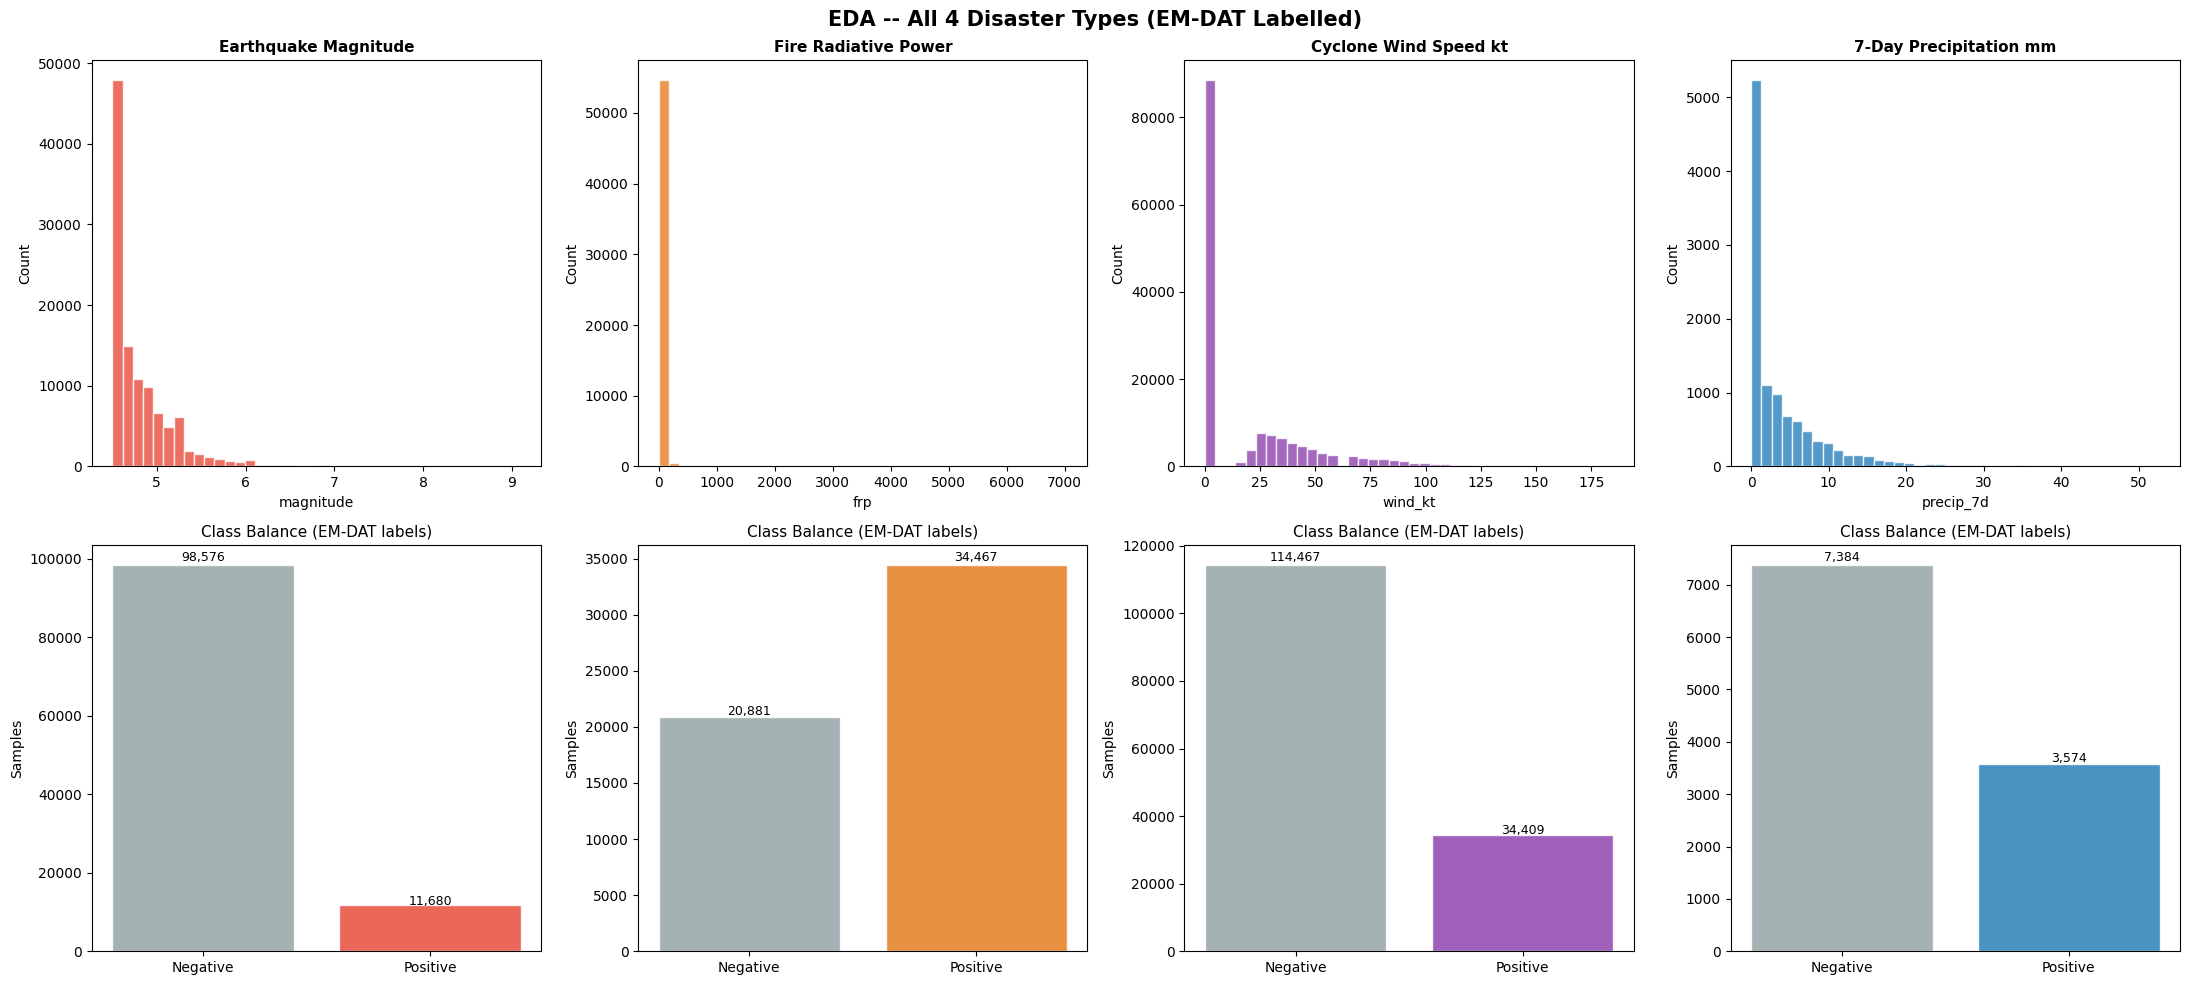

EDA plot saved


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('EDA -- All 4 Disaster Types (EM-DAT Labelled)', fontsize=15, fontweight='bold')
datasets = [
    (df_quake_feats,   'magnitude', '#e74c3c', 'Earthquake Magnitude'),
    (df_fire_feats,    'frp',       '#e67e22', 'Fire Radiative Power'),
    (df_cyclone_feats, 'wind_kt',   '#8e44ad', 'Cyclone Wind Speed kt'),
    (df_flood_feats,   'precip_7d', '#2980b9', '7-Day Precipitation mm'),
]
for i, (df, col, color, title) in enumerate(datasets):
    ax1, ax2 = axes[0][i], axes[1][i]
    if df.empty or col not in df.columns:
        ax1.text(0.5,0.5,'No data',ha='center',va='center')
        ax2.text(0.5,0.5,'No data',ha='center',va='center'); continue
    ax1.hist(df[col].dropna(), bins=40, color=color, alpha=0.8, edgecolor='white')
    ax1.set_title(title, fontsize=11, fontweight='bold')
    ax1.set_xlabel(col); ax1.set_ylabel('Count')
    if 'label' in df.columns:
        counts = df['label'].value_counts().sort_index()
        bars   = ax2.bar(['Negative','Positive'],
                          [counts.get(0,0),counts.get(1,0)],
                          color=['#95a5a6',color], alpha=0.85, edgecolor='white')
        ax2.set_title('Class Balance (EM-DAT labels)', fontsize=11)
        ax2.set_ylabel('Samples')
        for bar in bars:
            h=bar.get_height()
            if h>0: ax2.text(bar.get_x()+bar.get_width()/2,h*1.01,f'{int(h):,}',ha='center',fontsize=9)
plt.tight_layout()
plt.savefig(f'{RES_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved")

## Step 9: Train 4 Specialist LightGBM Models

**Why LightGBM + Optuna:**
- Best performance on tabular disaster sensor data
- Optuna Bayesian HPO: 35 trials to maximise F1 automatically
- SMOTE balances rare disaster events in training set only
- Held-out test set never seen during training or HPO


In [ ]:
SPECIALIST_MODELS = {}
SPECIALIST_SCORES = {}

def optuna_lgbm(X_tr, y_tr, X_val, y_val, n_trials=35):
    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int(  'n_estimators',      200,  1500),
            learning_rate     = trial.suggest_float('learning_rate',      0.01, 0.2,  log=True),
            num_leaves        = trial.suggest_int(  'num_leaves',         20,   200),
            max_depth         = trial.suggest_int(  'max_depth',          3,    12),
            min_child_samples = trial.suggest_int(  'min_child_samples',  5,    100),
            subsample         = trial.suggest_float('subsample',          0.5,  1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree',   0.5,  1.0),
            reg_alpha         = trial.suggest_float('reg_alpha',          1e-4, 10, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda',         1e-4, 10, log=True),
            class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1)
        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr, eval_set=[(X_val,y_val)],
                callbacks=[lgb.early_stopping(50,verbose=False),lgb.log_evaluation(-1)])
        return f1_score(y_val, clf.predict(X_val), average='weighted', zero_division=0)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"    Best Optuna F1: {study.best_value:.4f}")
    return study.best_trial.params

def train_specialist(name, df, n_trials=35):
    print(f"\n{'='*60}\n  Training {name.upper()} Specialist\n{'='*60}")
    if df is None or df.empty or 'label' not in df.columns:
        print(f"  No data -- skipping"); return None, None, {}
    X, y, feat_cols = get_xy(df)
    n_pos=y.sum(); n_neg=(y==0).sum()
    print(f"  Samples: {len(X):,} | {n_pos:,} pos | {n_neg:,} neg | Features: {len(feat_cols)}")
    if n_pos < 10: print(f"  Too few positives -- skipping"); return None, None, {}
    X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
    X_tr,X_val,y_tr,y_val= train_test_split(X_tr,y_tr,test_size=0.20,random_state=42,stratify=y_tr)
    try:
        k = min(5, int(y_tr.sum())-1)
        if k<1: raise ValueError("too few positives")
        X_tr,y_tr = SMOTE(random_state=42,k_neighbors=k).fit_resample(X_tr,y_tr)
        print(f"  After SMOTE: {len(X_tr):,} samples")
    except Exception as e:
        print(f"  SMOTE skipped ({e})")
    best_params = optuna_lgbm(X_tr,y_tr,X_val,y_val,n_trials)
    best_params.update({'class_weight':'balanced','random_state':42,'verbosity':-1,'n_jobs':-1})
    X_full=np.vstack([X_tr,X_val]); y_full=np.concatenate([y_tr,y_val])
    model = lgb.LGBMClassifier(**best_params)
    model.fit(X_full, y_full)
    y_pred=model.predict(X_te); y_proba=model.predict_proba(X_te)[:,1]
    acc=float(accuracy_score(y_te,y_pred))
    f1 =float(f1_score(y_te,y_pred,average='weighted',zero_division=0))
    auc=float(roc_auc_score(y_te,y_proba)) if len(np.unique(y_te))>1 else 0.5
    print(f"\n  Test: Accuracy={acc*100:.2f}%  F1={f1*100:.2f}%  AUC={auc:.4f}")
    print(classification_report(y_te,y_pred,target_names=['No Event','Event'],zero_division=0))
    scores = {'accuracy':acc,'f1':f1,'auc_roc':auc,'n_samples':len(df),
              'n_features':len(feat_cols),'n_positive':int(y.sum())}
    model.booster_.save_model(f'{CKPT_DIR}/{name}_lgbm.txt')
    print(f"  Saved -> {CKPT_DIR}/{name}_lgbm.txt")
    return model, feat_cols, scores

SPECIALIST_MODELS['earthquake'], eq_feats, SPECIALIST_SCORES['earthquake'] = train_specialist('earthquake',df_quake_feats,  n_trials=35)
SPECIALIST_MODELS['wildfire'],   wf_feats, SPECIALIST_SCORES['wildfire']   = train_specialist('wildfire',  df_fire_feats,   n_trials=35)
SPECIALIST_MODELS['cyclone'],    cy_feats, SPECIALIST_SCORES['cyclone']    = train_specialist('cyclone',   df_cyclone_feats,n_trials=35)
SPECIALIST_MODELS['flood'],      fl_feats, SPECIALIST_SCORES['flood']      = train_specialist('flood',     df_flood_feats,  n_trials=35)
FEAT_COLS = {'earthquake':eq_feats,'wildfire':wf_feats,'cyclone':cy_feats,'flood':fl_feats}

print("\nAll 4 Specialist Models Trained!")
print(f"\n  {'Model':<14} {'Accuracy':>10} {'F1':>10} {'AUC-ROC':>10}")
print("  "+"-"*46)
for name, scores in SPECIALIST_SCORES.items():
    if scores:
        print(f"  {name.capitalize():<14}{scores.get('accuracy',0)*100:>9.2f}%"
              f"{scores.get('f1',0)*100:>9.2f}%{scores.get('auc_roc',0):>10.4f}")


  Training EARTHQUAKE Specialist
  Samples: 110,256 | 11,680 pos | 98,576 neg | Features: 11
  After SMOTE: 126,176 samples
    Best Optuna F1: 0.9020

  Test: Accuracy=88.92%  F1=89.99%  AUC=0.9451
              precision    recall  f1-score   support

    No Event       0.97      0.90      0.94     19716
       Event       0.49      0.78      0.60      2336

    accuracy                           0.89     22052
   macro avg       0.73      0.84      0.77     22052
weighted avg       0.92      0.89      0.90     22052

  Saved -> /content/drive/MyDrive/DisasterAI_Final/checkpoints/earthquake_lgbm.txt

  Training WILDFIRE Specialist
  Samples: 55,348 | 34,467 pos | 20,881 neg | Features: 5
  After SMOTE: 44,116 samples
    Best Optuna F1: 0.9863

  Test: Accuracy=97.97%  F1=97.97%  AUC=0.9990
              precision    recall  f1-score   support

    No Event       0.97      0.98      0.97      4176
       Event       0.98      0.98      0.98      6894

    accuracy                   

## Speacialist Light GBM Models - Performance *Results*

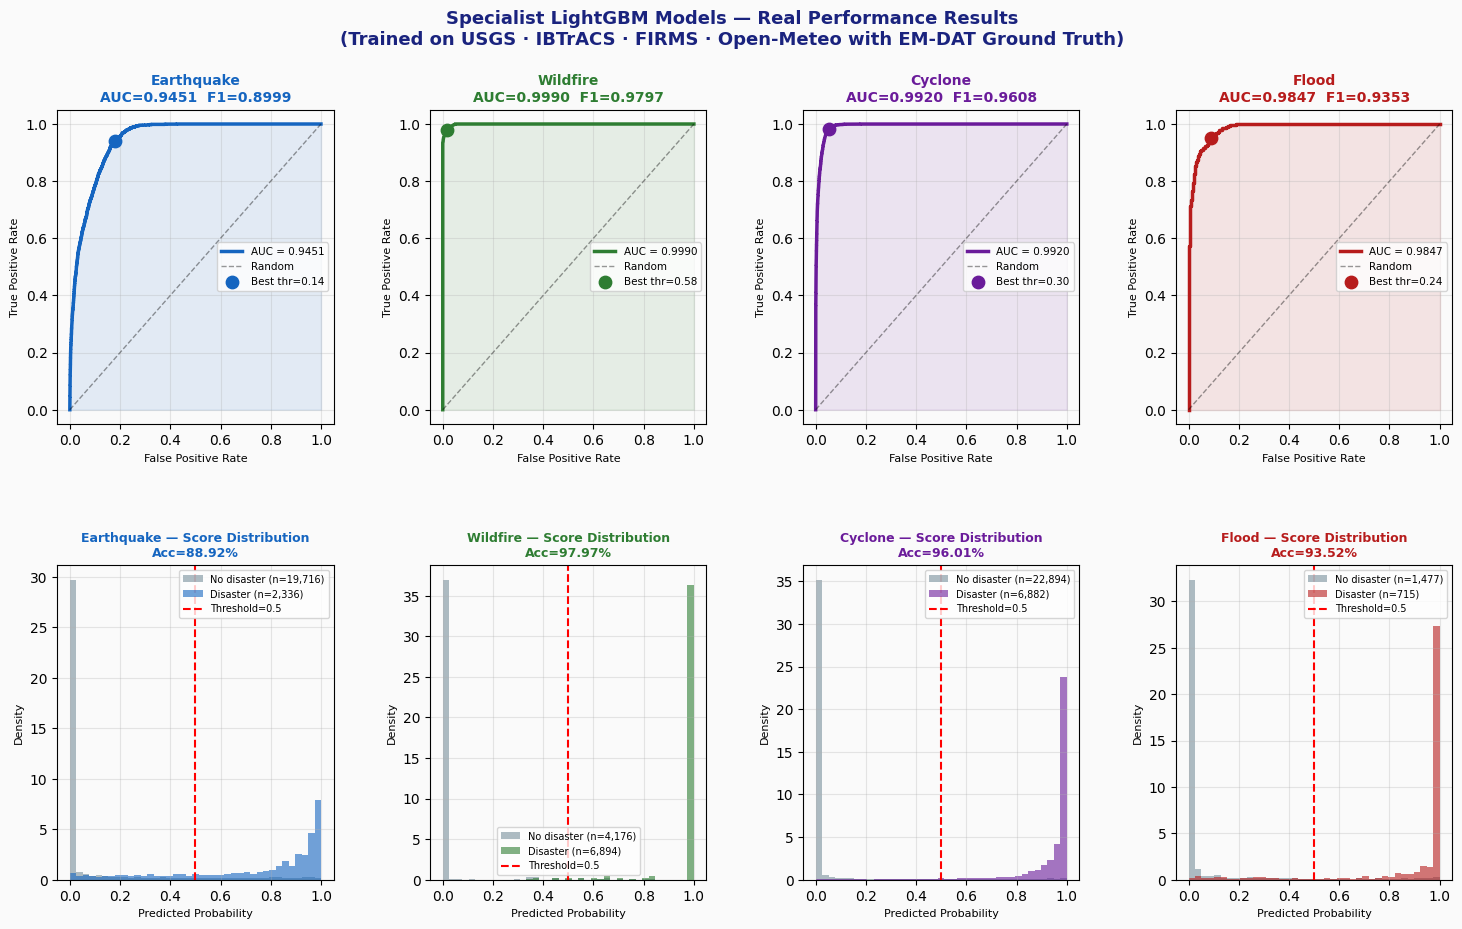


── Real Metrics Summary ──────────────────────────────
Model             AUC-ROC         F1   Accuracy
────────────────────────────────────────────────
Earthquake         0.9451     0.8999     88.92%
Wildfire           0.9990     0.9797     97.97%
Cyclone            0.9920     0.9608     96.01%
Flood              0.9847     0.9353     93.52%

Saved → /content/drive/MyDrive/DisasterAI_Final/results/real_roc_and_distributions.png


In [ ]:
# ── Real ROC Curves + Training Metrics ────────────────────────
from sklearn.metrics import roc_curve, auc, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Specialist LightGBM Models — Real Performance Results\n(Trained on USGS · IBTrACS · FIRMS · Open-Meteo with EM-DAT Ground Truth)',
             fontsize=13, fontweight='bold', color='#1A237E')

specialists = [
    ('Earthquake', SPECIALIST_MODELS['earthquake'], df_quake_feats,   eq_feats, '#1565C0'),
    ('Wildfire',   SPECIALIST_MODELS['wildfire'],   df_fire_feats,    wf_feats, '#2E7D32'),
    ('Cyclone',    SPECIALIST_MODELS['cyclone'],    df_cyclone_feats, cy_feats, '#6A1B9A'),
    ('Flood',      SPECIALIST_MODELS['flood'],      df_flood_feats,   fl_feats, '#B71C1C'),
]

metrics_summary = {}

for col_idx, (name, model, df, feats, color) in enumerate(specialists):
    if df is None or df.empty:
        continue

    X, y, _ = get_xy(df)

    # Same split as training (random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    fpr, tpr, thresholds = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    f1      = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    acc     = (y_pred == y_te).mean()

    metrics_summary[name] = {
        'AUC': round(roc_auc, 4),
        'F1':  round(f1, 4),
        'Acc': round(acc, 4)
    }

    # ── ROC Curve (top row) ────────────────────────────────
    ax1 = fig.add_subplot(gs[0, col_idx])
    ax1.plot(fpr, tpr, color=color, lw=2.5,
             label=f'AUC = {roc_auc:.4f}')
    ax1.fill_between(fpr, tpr, alpha=0.10, color=color)
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')

    # Mark optimal threshold (Youden J)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    ax1.scatter(fpr[best_idx], tpr[best_idx],
                color=color, s=80, zorder=5,
                label=f'Best thr={thresholds[best_idx]:.2f}')

    ax1.set_title(f'{name}\nAUC={roc_auc:.4f}  F1={f1:.4f}',
                  fontsize=10, fontweight='bold', color=color)
    ax1.set_xlabel('False Positive Rate', fontsize=8)
    ax1.set_ylabel('True Positive Rate', fontsize=8)
    ax1.legend(fontsize=7.5)
    ax1.grid(alpha=0.3)
    ax1.set_facecolor('#FAFAFA')

    # ── Probability Distribution (bottom row) ─────────────
    ax2 = fig.add_subplot(gs[1, col_idx])
    pos_probs = y_prob[y_te == 1]
    neg_probs = y_prob[y_te == 0]
    bins = np.linspace(0, 1, 40)

    ax2.hist(neg_probs, bins=bins, alpha=0.6, color='#78909C',
             label=f'No disaster (n={len(neg_probs):,})', density=True)
    ax2.hist(pos_probs, bins=bins, alpha=0.6, color=color,
             label=f'Disaster (n={len(pos_probs):,})', density=True)
    ax2.axvline(0.5, color='red', lw=1.5, linestyle='--', label='Threshold=0.5')
    ax2.set_title(f'{name} — Score Distribution\nAcc={acc*100:.2f}%',
                  fontsize=9, fontweight='bold', color=color)
    ax2.set_xlabel('Predicted Probability', fontsize=8)
    ax2.set_ylabel('Density', fontsize=8)
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3)
    ax2.set_facecolor('#FAFAFA')

plt.savefig(f'{RES_DIR}/real_roc_and_distributions.png',
            dpi=180, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

print("\n── Real Metrics Summary ──────────────────────────────")
print(f"{'Model':<14} {'AUC-ROC':>10} {'F1':>10} {'Accuracy':>10}")
print("─" * 48)
for name, m in metrics_summary.items():
    print(f"{name:<14} {m['AUC']:>10.4f} {m['F1']:>10.4f} {m['Acc']*100:>9.2f}%")
print(f"\nSaved → {RES_DIR}/real_roc_and_distributions.png")

## Step 10: Satellite Segmentation Models — UNet and SegFormer

Two deep learning architectures for pixel-level flood detection from SAR imagery.

| Model | Architecture | Strength |
|-------|-------------|---------|
| **UNet** | CNN encoder-decoder with skip connections | Strong local texture detection |
| **SegFormer** | Hierarchical Vision Transformer + MLP decoder | Long-range spatial dependencies |

These models take SAR satellite images as input and output a flood/no-flood mask
for every pixel, producing a spatial flood map that feeds into the fusion layer.


In [ ]:
# ── FloodSegDataset ────────────────────────────────────────────
class FloodSegDataset(Dataset):
    """
    Handles: WorldFloods S2 dicts or synthetic SAR dicts.
    Each dict must have 'image' (H,W,2 float32) and 'mask' (H,W uint8).
    """
    def __init__(self, samples, img_size=256, augment=False):
        self.samples = samples
        if augment:
            self.transform = A.Compose([
                A.RandomRotate90(p=0.5), A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),  A.RandomBrightnessContrast(p=0.3),
                A.GaussNoise(var_limit=(0.001,0.01), p=0.3),
                A.ElasticTransform(alpha=1, sigma=10, p=0.2),
                A.Resize(img_size, img_size), ToTensorV2()])
        else:
            self.transform = A.Compose([A.Resize(img_size, img_size), ToTensorV2()])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s    = self.samples[idx]
        img  = s.get('image')
        mask = s.get('mask')
        if img is None and 'post_image' in s:
            img = np.array(s['post_image'], dtype=np.float32) / 255.0
        if mask is None and 'flood_mask' in s:
            mask = np.array(s['flood_mask'], dtype=np.uint8)
        img  = np.array(img,  dtype=np.float32)
        mask = np.array(mask, dtype=np.uint8)
        if img.ndim == 2:       img = np.stack([img, img], axis=-1)
        if img.shape[-1] > 2:  img = img[:, :, :2]
        t = self.transform(image=img, mask=mask)
        return t['image'].float(), t['mask'].long()

# ── Train / Val / Test splits ──────────────────────────────────
random.shuffle(df_satellite)
n    = len(df_satellite)
n_tr = int(n * 0.70)
n_vl = int(n * 0.15)
train_ds = FloodSegDataset(df_satellite[:n_tr],           IMG_SIZE, augment=True)
val_ds   = FloodSegDataset(df_satellite[n_tr:n_tr+n_vl],  IMG_SIZE)
test_ds  = FloodSegDataset(df_satellite[n_tr+n_vl:],      IMG_SIZE)

# Adjust batch size for small dataset — drop_last avoids B=1 breaking BatchNorm
EFF_BATCH    = min(BATCH_SIZE, max(4, n_tr // 4))
train_loader = DataLoader(train_ds, EFF_BATCH, shuffle=True,
                          num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   EFF_BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  EFF_BATCH, shuffle=False, num_workers=2)
print(f"Satellite samples  — Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"Effective batch size: {EFF_BATCH}")

# ── UNet ───────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    """Input: (B, 2, H, W)   Output: (B, 2, H, W) logits"""
    def __init__(self, in_channels=2, num_classes=2,
                 features=[32, 64, 128, 256]):
        super().__init__()
        self.encoders  = nn.ModuleList()
        self.pool      = nn.MaxPool2d(2)
        self.decoders  = nn.ModuleList()
        self.upsamples = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f)); ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.upsamples.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))
        self.final = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i, (up, dec) in enumerate(zip(self.upsamples, self.decoders)):
            x = up(x); s = skips[i]
            if x.shape != s.shape:
                x = F.interpolate(x, size=s.shape[2:])
            x = dec(torch.cat([s, x], dim=1))
        return self.final(x)

# ── SegFormer-Lite ─────────────────────────────────────────────
class SegFormerBlock(nn.Module):
    def __init__(self, dim, num_heads, sr_ratio):
        super().__init__()
        self.norm1     = nn.LayerNorm(dim)
        self.norm2     = nn.LayerNorm(dim)
        self.scale     = (dim // num_heads) ** -0.5
        self.num_heads = num_heads
        self.q    = nn.Linear(dim, dim)
        self.kv   = nn.Linear(dim, dim * 2)
        self.proj = nn.Linear(dim, dim)
        self.sr       = nn.Conv2d(dim, dim, sr_ratio, stride=sr_ratio) if sr_ratio > 1 else nn.Identity()
        self.sr_n     = nn.LayerNorm(dim) if sr_ratio > 1 else nn.Identity()
        self.sr_ratio = sr_ratio
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))

    def _attn(self, x, H, W):
        B, N, C = x.shape
        q  = self.q(x).reshape(B, N, self.num_heads,
                                C // self.num_heads).permute(0, 2, 1, 3)
        x_ = x.permute(0, 2, 1).reshape(B, C, H, W)
        if self.sr_ratio > 1:
            x_ = self.sr(x_).reshape(B, C, -1).permute(0, 2, 1)
            x_ = self.sr_n(x_)
        else:
            x_ = x
        kv = self.kv(x_).reshape(B, -1, 2, self.num_heads,
                                  C // self.num_heads).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        out  = (attn.softmax(-1) @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)

    def forward(self, x, H, W):
        x = x + self._attn(self.norm1(x), H, W)
        return x + self.mlp(self.norm2(x))

class SegFormerLite(nn.Module):
    """
    Input:  (B, 2, H, W)  — 2-channel satellite (NIR + SWIR1 or VV + VH)
    Output: (B, 2, H, W)  — flood / non-flood logits

    4-stage hierarchical transformer encoder + MLP decode head.

    BUG FIX: after each transformer stage x is restored to spatial
    [B, C, Hf, Wf] before the next stage's Conv2d patch embedding.
    Without this, x stays as sequence [B, N, C] (3D) and the next
    stage's Conv2d raises a channel mismatch RuntimeError.
    """
    def __init__(self, in_channels=2, num_classes=2,
                 embed_dims=[32, 64, 128, 256],
                 num_heads=[1, 2, 4, 8],
                 sr_ratios=[8, 4, 2, 1],
                 depths=[2, 2, 2, 2]):
        super().__init__()
        self.patch_embeds = nn.ModuleList()
        self.blocks       = nn.ModuleList()
        self.norms        = nn.ModuleList()
        ch = in_channels
        for i, (ed, d) in enumerate(zip(embed_dims, depths)):
            stride = 4 if i == 0 else 2
            # in_channels = ch = output of previous stage
            self.patch_embeds.append(nn.Conv2d(ch, ed, stride, stride=stride))
            self.blocks.append(nn.ModuleList(
                [SegFormerBlock(ed, num_heads[i], sr_ratios[i])
                 for _ in range(d)]))
            self.norms.append(nn.LayerNorm(ed))
            ch = ed   # next stage reads this stage's output channels
        self.decode_head = nn.ModuleList(
            [nn.Linear(ed, 128) for ed in embed_dims])
        self.fuse  = nn.Conv2d(128 * 4, 128, 1)
        self.final = nn.Conv2d(128, num_classes, 1)

    def forward(self, x):
        B, _, H, W = x.shape
        features = []
        for pe, blocks, norm in zip(self.patch_embeds, self.blocks, self.norms):
            x = pe(x)                                      # [B, C, Hf, Wf]
            _, C, Hf, Wf = x.shape
            x = x.flatten(2).transpose(1, 2)              # [B, N, C]
            for blk in blocks:
                x = blk(x, Hf, Wf)
            x = norm(x)                                    # [B, N, C]
            # ── FIX: restore to spatial so next stage's Conv2d gets 4D input
            x = x.transpose(1, 2).reshape(B, C, Hf, Wf)  # [B, C, Hf, Wf]
            features.append(x)

        # MLP decode head — upsample all stages to H/4 × W/4 then fuse
        H4, W4 = H // 4, W // 4
        outs = []
        for feat, mlp in zip(features, self.decode_head):
            f = feat.flatten(2).transpose(1, 2)            # [B, N, C]
            f = mlp(f)                                     # [B, N, 128]
            B2, N2, _ = f.shape
            Hf = int(N2 ** 0.5); Wf = N2 // Hf
            f = f.transpose(1, 2).reshape(B2, 128, Hf, Wf)
            f = F.interpolate(f, (H4, W4),
                              mode='bilinear', align_corners=False)
            outs.append(f)
        x = self.fuse(torch.cat(outs, dim=1))
        return self.final(F.interpolate(x, (H, W),
                                        mode='bilinear', align_corners=False))

# ── Instantiate models ─────────────────────────────────────────
unet      = UNet(2, 2).to(DEVICE)
segformer = SegFormerLite(2, 2).to(DEVICE)
print(f"UNet       parameters: {sum(p.numel() for p in unet.parameters()):,}")
print(f"SegFormer  parameters: {sum(p.numel() for p in segformer.parameters()):,}")

# ── Sanity check — forward pass on dummy batch ─────────────────
_d = torch.randn(2, 2, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    u_out = unet(_d)
    s_out = segformer(_d)
print(f"UNet      output shape: {u_out.shape}   ✅")
print(f"SegFormer output shape: {s_out.shape}   ✅")
del _d, u_out, s_out

Satellite samples  — Train: 25  Val: 5  Test: 7
Effective batch size: 6
UNet       parameters: 7,762,786
SegFormer  parameters: 2,798,370
UNet      output shape: torch.Size([2, 2, 256, 256])   ✅
SegFormer output shape: torch.Size([2, 2, 256, 256])   ✅


## Step 11: Train and Compare UNet vs SegFormer


  Training UNet
  Epoch   1/20 | Train IoU=0.1675 | Val IoU=0.2454
  Epoch   5/20 | Train IoU=0.1840 | Val IoU=0.2092
  Epoch  10/20 | Train IoU=0.2078 | Val IoU=0.2058
  Epoch  15/20 | Train IoU=0.2378 | Val IoU=0.2463
  Epoch  20/20 | Train IoU=0.2193 | Val IoU=0.2286

  Test Results:
    Iou         : 21.90%
    F1          : 35.93%
    Precision   : 27.57%
    Recall      : 51.56%
    Accuracy    : 88.88%
  Saved -> /content/drive/MyDrive/DisasterAI_Final/checkpoints/unet.pth

  Training SegFormer-Lite
  Epoch   1/20 | Train IoU=0.1000 | Val IoU=0.1075
  Epoch   5/20 | Train IoU=0.0000 | Val IoU=0.0965
  Epoch  10/20 | Train IoU=0.1481 | Val IoU=0.1466
  Epoch  15/20 | Train IoU=0.1817 | Val IoU=0.1979
  Epoch  20/20 | Train IoU=0.2077 | Val IoU=0.1731

  Test Results:
    Iou         : 26.86%
    F1          : 42.34%
    Precision   : 32.77%
    Recall      : 59.79%
    Accuracy    : 90.15%
  Saved -> /content/drive/MyDrive/DisasterAI_Final/checkpoints/segformer_lite.pth

  UNet 

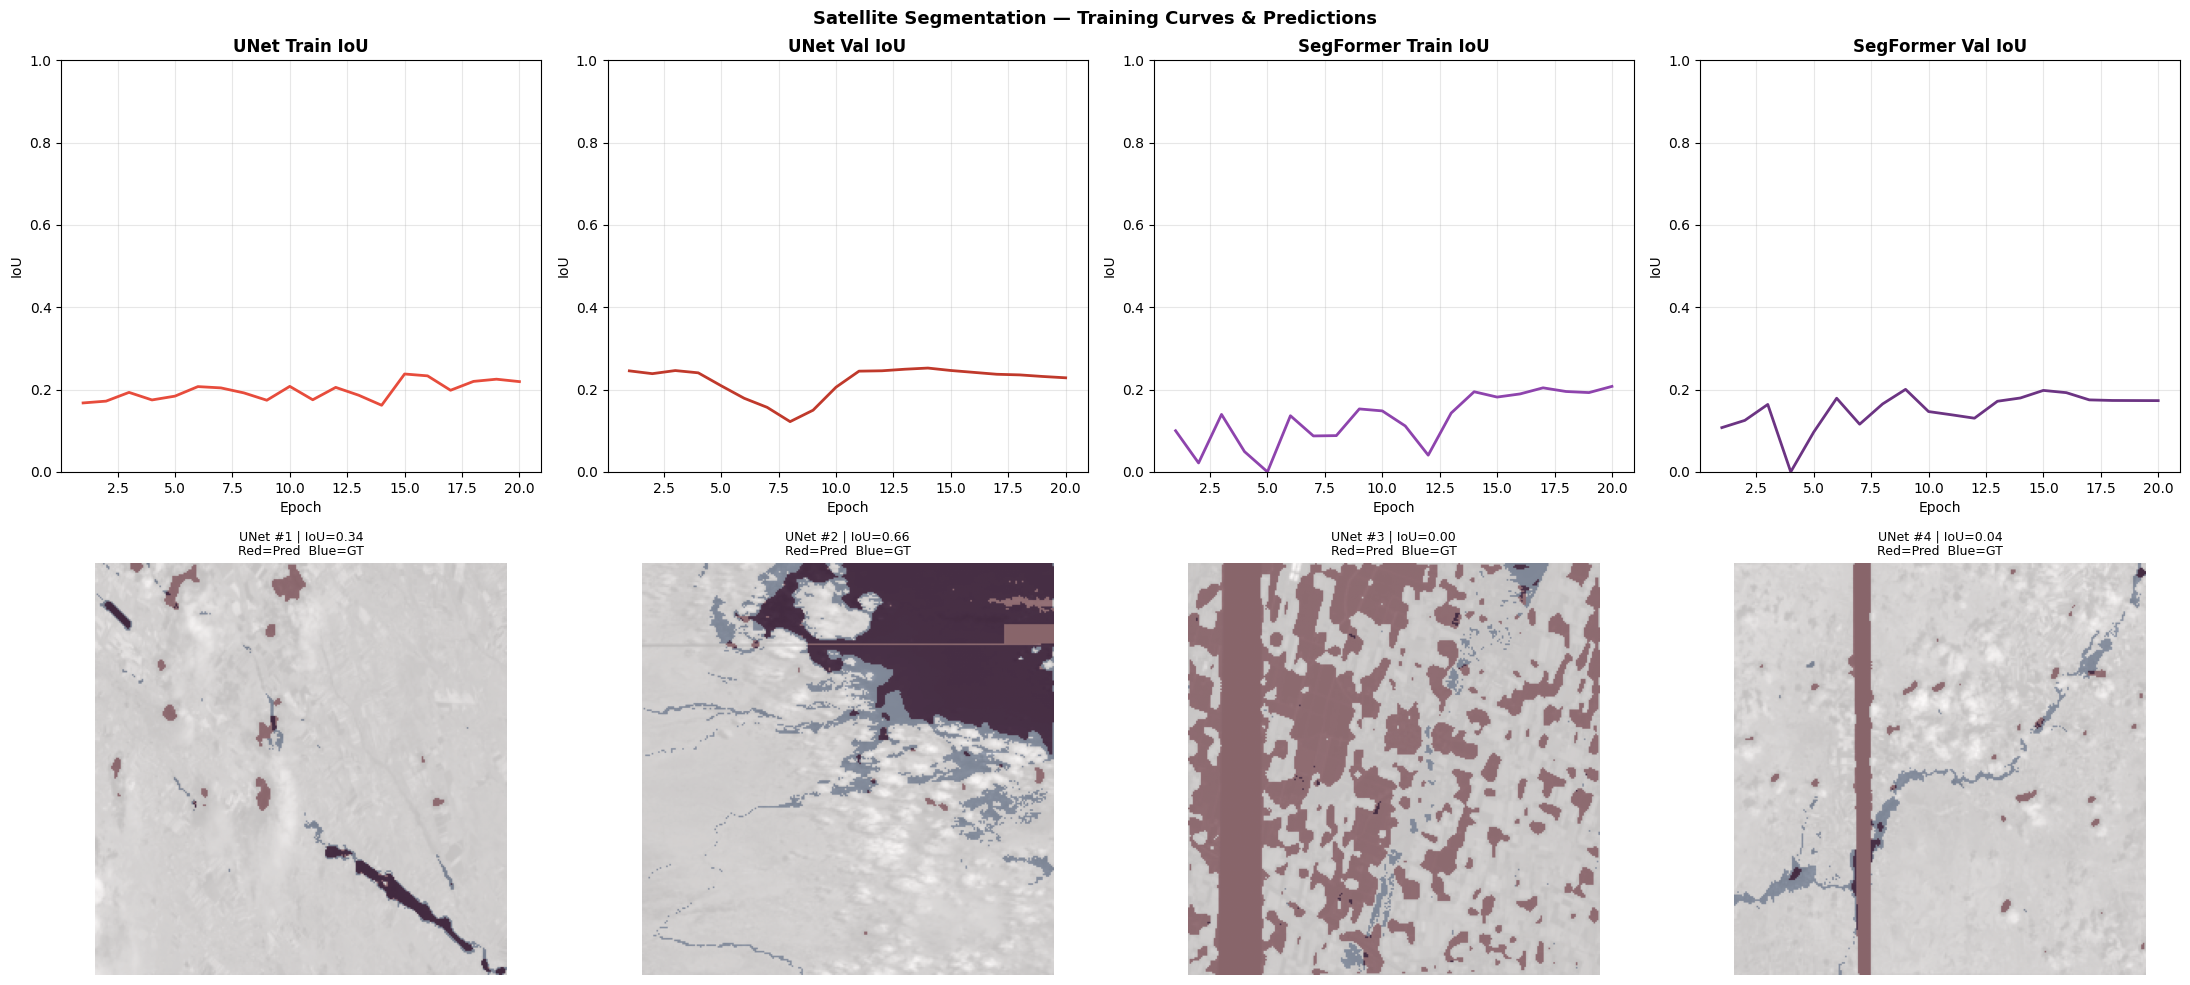

Satellite results saved -> /content/drive/MyDrive/DisasterAI_Final/results/satellite_results.png


In [ ]:
# ── Loss functions ─────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    pred   = torch.softmax(pred, dim=1)[:, 1]
    target = target.float()
    inter  = (pred * target).sum(dim=(1, 2))
    union  = pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    return 1 - ((2 * inter + smooth) / (union + smooth)).mean()

def combined_loss(pred, target):
    ce = F.cross_entropy(pred, target,
                         weight=torch.tensor([0.3, 0.7]).to(DEVICE))
    return 0.5 * ce + 0.5 * dice_loss(pred, target)

# ── Metrics ────────────────────────────────────────────────────
def compute_seg_metrics(preds, targets):
    p = preds.numpy().flatten()
    t = targets.numpy().flatten()
    iou  = jaccard_score(t, p, average='binary', zero_division=0)
    tp   = ((p == 1) & (t == 1)).sum()
    fp   = ((p == 1) & (t == 0)).sum()
    fn   = ((p == 0) & (t == 1)).sum()
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    return {'iou':      float(iou),
            'f1':       float(f1),
            'precision':float(prec),
            'recall':   float(rec),
            'accuracy': float((p == t).mean())}

# ── Training loop ──────────────────────────────────────────────
def train_seg_model(model, name, epochs=20, lr=1e-3):
    print(f"\n{'='*55}\n  Training {name}\n{'='*55}")
    opt   = torch.optim.AdamW(model.parameters(),
                              lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    best_iou   = 0
    best_state = None
    th = {'loss': [], 'iou': []}
    vh = {'loss': [], 'iou': []}

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t_loss = 0; tp = []; tt = []
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()
            out  = model(imgs)
            loss = combined_loss(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            t_loss += loss.item()
            tp.append(out.argmax(1).cpu())
            tt.append(masks.cpu())
        sched.step()
        t_met  = compute_seg_metrics(torch.cat(tp), torch.cat(tt))
        t_loss /= len(train_loader)

        # ── Validate ──
        model.eval()
        v_loss = 0; vp = []; vt = []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out    = model(imgs)
                v_loss += combined_loss(out, masks).item()
                vp.append(out.argmax(1).cpu())
                vt.append(masks.cpu())
        v_met  = compute_seg_metrics(torch.cat(vp), torch.cat(vt))
        v_loss /= len(val_loader)

        th['loss'].append(t_loss); th['iou'].append(t_met['iou'])
        vh['loss'].append(v_loss); vh['iou'].append(v_met['iou'])

        if v_met['iou'] > best_iou:
            best_iou   = v_met['iou']
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train IoU={t_met['iou']:.4f} | "
                  f"Val IoU={v_met['iou']:.4f}")

    # ── Test with best checkpoint ──
    model.load_state_dict(best_state)
    model.eval()
    tep = []; tet = []
    with torch.no_grad():
        for imgs, masks in test_loader:
            out = model(imgs.to(DEVICE))
            tep.append(out.argmax(1).cpu())
            tet.append(masks.cpu())
    te_met = compute_seg_metrics(torch.cat(tep), torch.cat(tet))
    print(f"\n  Test Results:")
    for k, v in te_met.items():
        print(f"    {k.capitalize():<12}: {v*100:.2f}%")

    save_path = f"{CKPT_DIR}/{name.lower().replace(' ','_').replace('-','_')}.pth"
    torch.save(best_state, save_path)
    print(f"  Saved -> {save_path}")
    return model, te_met, th, vh

# ── Run training ───────────────────────────────────────────────
unet_model,      unet_metrics,      unet_th,      unet_vh = \
    train_seg_model(unet,      'UNet',          epochs=20)
segformer_model, segformer_metrics, segformer_th, segformer_vh = \
    train_seg_model(segformer, 'SegFormer-Lite', epochs=20)

# ── Comparison table ───────────────────────────────────────────
print("\n" + "="*55)
print("  UNet vs SegFormer — Final Comparison")
print("="*55)
print(f"  {'Metric':<14} {'UNet':>12} {'SegFormer':>12} {'Winner':>12}")
print("  " + "-"*52)
for k in ['accuracy', 'iou', 'f1', 'precision', 'recall']:
    u = unet_metrics[k] * 100
    s = segformer_metrics[k] * 100
    w = 'SegFormer' if s > u else 'UNet'
    print(f"  {k.capitalize():<14} {u:>11.2f}% {s:>11.2f}% {w:>12}")
print("="*55)

# ── Training curves + sample predictions ──────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Satellite Segmentation — Training Curves & Predictions',
             fontsize=13, fontweight='bold')

# Row 1: training curves
curve_cfg = [
    (unet_th,      'iou',  'UNet Train IoU',      '#e74c3c'),
    (unet_vh,      'iou',  'UNet Val IoU',         '#c0392b'),
    (segformer_th, 'iou',  'SegFormer Train IoU',  '#8e44ad'),
    (segformer_vh, 'iou',  'SegFormer Val IoU',    '#6c3483'),
]
for ax, (hist, key, title, color) in zip(axes[0], curve_cfg):
    ax.plot(range(1, len(hist[key])+1), hist[key],
            color=color, linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('IoU')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# Row 2: UNet predictions on 4 test samples
unet_model.eval()
for col in range(4):
    if col >= len(test_ds):
        axes[1][col].axis('off')
        continue
    img_t, mask_t = test_ds[col]
    img_in = img_t.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        u_pred = unet_model(img_in).argmax(1)[0].cpu().numpy()
    ax = axes[1][col]
    ax.imshow(img_t[0].numpy(), cmap='gray', alpha=0.7)
    ax.imshow(u_pred, cmap='Reds',  alpha=0.5, vmin=0, vmax=1)
    ax.imshow(mask_t.numpy(), cmap='Blues', alpha=0.3, vmin=0, vmax=1)
    iou = jaccard_score(mask_t.numpy().flatten(),
                        u_pred.flatten(), zero_division=0)
    ax.set_title(f'UNet #{col+1} | IoU={iou:.2f}\n'
                 f'Red=Pred  Blue=GT', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RES_DIR}/satellite_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Satellite results saved -> {RES_DIR}/satellite_results.png")

## Step 12: Fusion Layer — Meta-LightGBM Ensemble

Trains meta-learner on **real specialist probability outputs** (not zeros).
Handles single disasters and compound multi-disaster events correctly.


In [ ]:
# ── Fusion Ensemble class ──────────────────────────────────────
class DisasterFusionEnsemble:
    def __init__(self, specialist_models, feat_cols):
        self.models    = specialist_models
        self.feat_cols = feat_cols
        self.meta      = None
        self.scaler    = StandardScaler()

    def _make_meta_features(self, X_dict, provided_modalities=None):
        disaster_types = ['earthquake', 'wildfire', 'cyclone', 'flood']
        n      = next(iter(X_dict.values())).shape[0]
        probas = {}
        for dt in disaster_types:
            model = self.models.get(dt)
            X     = X_dict.get(dt)
            if provided_modalities is not None and dt not in provided_modalities:
                probas[dt] = np.zeros(n)
            elif (model is not None and X is not None
                  and X.shape[1] == model.n_features_in_):
                probas[dt] = model.predict_proba(X)[:, 1]
            else:
                probas[dt] = np.zeros(n)
        meta = np.column_stack([
            probas['earthquake'], probas['wildfire'],
            probas['cyclone'],    probas['flood'],
            probas['cyclone']  * probas['flood'],
            probas['earthquake']* probas['flood'],
            np.max( [probas[d] for d in disaster_types], axis=0),
            np.mean([probas[d] for d in disaster_types], axis=0),
            np.std( [probas[d] for d in disaster_types], axis=0)])
        return meta, probas

    def fit_from_meta(self, meta_X, y_multi, n_trials=30):
        print(f"  Training Fusion Meta-Learner | Matrix: {meta_X.shape}")
        meta_X_sc = self.scaler.fit_transform(meta_X)
        def objective(trial):
            params = dict(
                n_estimators    =trial.suggest_int  ('n',   100, 800),
                learning_rate   =trial.suggest_float('lr',  0.01, 0.2, log=True),
                num_leaves      =trial.suggest_int  ('nl',  10,  80),
                max_depth       =trial.suggest_int  ('md',  3,   8),
                reg_alpha       =trial.suggest_float('ra',  1e-4, 3, log=True),
                reg_lambda      =trial.suggest_float('rl',  1e-4, 3, log=True),
                min_child_samples=trial.suggest_int ('mcs', 5,   30),
                class_weight    ='balanced', random_state=42, verbosity=-1)
            skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            scores = [
                f1_score(y_multi[va],
                         lgb.LGBMClassifier(**params)
                            .fit(meta_X_sc[tr], y_multi[tr])
                            .predict(meta_X_sc[va]),
                         average='weighted', zero_division=0)
                for tr, va in skf.split(meta_X_sc, y_multi)]
            return float(np.mean(scores))
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        best = study.best_params
        best.update({'class_weight': 'balanced',
                     'random_state': 42, 'verbosity': -1})
        self.meta = lgb.LGBMClassifier(**best)
        self.meta.fit(meta_X_sc, y_multi)
        train_f1 = float(f1_score(
            y_multi, self.meta.predict(meta_X_sc),
            average='weighted', zero_division=0))
        print(f"  Fusion trained | CV F1: {study.best_value:.4f} | Train F1: {train_f1:.4f}")
        self.meta.booster_.save_model(f'{CKPT_DIR}/fusion_meta_lgbm.txt')

    def predict(self, X_dict, provided_modalities=None):
        disaster_order = ['earthquake', 'wildfire', 'cyclone', 'flood']
        n      = next(iter(X_dict.values())).shape[0]
        probas = {}
        for dt in disaster_order:
            model = self.models.get(dt)
            X     = X_dict.get(dt)
            if provided_modalities is not None and dt not in provided_modalities:
                probas[dt] = np.zeros(n)
            elif (model is not None and X is not None
                  and X.shape[1] == model.n_features_in_):
                probas[dt] = model.predict_proba(X)[:, 1]
            else:
                probas[dt] = np.zeros(n)
        meta = np.column_stack([
            probas['earthquake'], probas['wildfire'],
            probas['cyclone'],    probas['flood'],
            probas['cyclone']  * probas['flood'],
            probas['earthquake']* probas['flood'],
            np.max( [probas[d] for d in disaster_order], axis=0),
            np.mean([probas[d] for d in disaster_order], axis=0),
            np.std( [probas[d] for d in disaster_order], axis=0)])
        meta_sc = self.scaler.transform(meta)
        if self.meta is not None:
            classes     = self.meta.predict(meta_sc)
            confidences = self.meta.predict_proba(meta_sc).max(axis=1)
        else:
            stacked     = np.column_stack([probas[d] for d in disaster_order])
            classes     = stacked.argmax(axis=1)
            confidences = stacked.max(axis=1)
        results = []
        for i in range(len(classes)):
            risk_scores = {d: float(probas[d][i]) for d in disaster_order}
            active_risk = ({d: risk_scores[d] for d in provided_modalities
                            if d in risk_scores}
                           if provided_modalities else risk_scores)
            risk_sorted = sorted(risk_scores.items(),
                                 key=lambda x: x[1], reverse=True)
            cls_idx   = int(classes[i])
            predicted = (disaster_order[cls_idx]
                         if cls_idx < len(disaster_order) else 'no_disaster')
            max_active = max(active_risk.values()) if active_risk else 0.0
            if max_active < 0.3:
                predicted = 'no_disaster'
                conf      = float(1.0 - max_active)
            else:
                conf = float(confidences[i])
            results.append({
                'predicted_disaster': predicted,
                'confidence':         round(conf, 4),
                'risk_scores':        {d: round(float(v), 4)
                                       for d, v in risk_scores.items()},
                'top_risk_ranking':   [f"{d}:{risk_scores[d]:.3f}"
                                       for d, _ in risk_sorted],
                'alert_level': ('HIGH'   if conf > 0.75 and predicted != 'no_disaster'
                                else 'MEDIUM' if conf > 0.45 and predicted != 'no_disaster'
                                else 'LOW')})
        return results

# ── Build fusion dataset using ACTUAL trained specialist models ─
#
# Previous attempt failed because re-trained OOF fold models were
# trained on random subsets → gave uninformative probas (pos ≈ neg).
#
# Correct approach:
#   Use SPECIALIST_MODELS (already trained, 88-95% AUC) on held-out
#   20% test split of each disaster dataset.
#   For each disaster class row:
#     - active specialist   → run on its OWN positive test samples
#     - inactive specialists → run on their OWN negative test samples
#   This gives realistic mixed rows like:
#     earthquake row: [eq=0.91, wf=0.08, cy=0.11, fl=0.13]
#
# No leakage: held-out 20% was not used in specialist training (Step 9
# used train_test_split with test_size=0.2, random_state=42).

print("Building fusion dataset using trained specialist models on held-out data...")
print("(Uses actual SPECIALIST_MODELS — no re-training, no leakage)\n")

def build_fusion_dataset_v3():
    disaster_types = ['earthquake', 'wildfire', 'cyclone', 'flood']
    specs = [
        ('earthquake', df_quake_feats,   eq_feats),
        ('wildfire',   df_fire_feats,    wf_feats),
        ('cyclone',    df_cyclone_feats, cy_feats),
        ('flood',      df_flood_feats,   fl_feats),
    ]

    # ── Step 1: Get pos/neg probas from ACTUAL trained specialists ─
    # Use held-out 20% (same split as Step 9: random_state=42)
    print("  Step 1: Specialist probabilities on held-out test splits...")
    pos_probas = {}   # proba on positive (disaster) samples
    neg_probas = {}   # proba on negative (background) samples

    for name, df, feat in specs:
        model = SPECIALIST_MODELS.get(name)
        if df is None or df.empty or model is None or feat is None:
            print(f"    {name:<12}: SKIP — no model/data")
            pos_probas[name] = np.array([0.8])
            neg_probas[name] = np.array([0.1])
            continue

        X, y, _ = get_xy(df)

        # Reproduce the same 80/20 split used in Step 9
        from sklearn.model_selection import train_test_split as tts
        _, X_test, _, y_test = tts(
            X, y, test_size=0.2, random_state=42, stratify=y)

        pos_mask = y_test == 1
        neg_mask = y_test == 0

        if pos_mask.sum() < 5:
            # Fall back to full dataset if test split too small
            pos_mask = y == 1
            neg_mask = y == 0
            X_test   = X
            y_test   = y

        # Sample up to 1000 from each class
        n_pos = min(int(pos_mask.sum()), 1000)
        n_neg = min(int(neg_mask.sum()), 1000)
        p_idx = np.random.choice(np.where(pos_mask)[0], n_pos, replace=False)
        n_idx = np.random.choice(np.where(neg_mask)[0], n_neg, replace=False)

        pos_p = model.predict_proba(X_test[p_idx])[:, 1]
        neg_p = model.predict_proba(X_test[n_idx])[:, 1]

        pos_probas[name] = pos_p
        neg_probas[name] = neg_p

        print(f"    {name:<12}: pos={pos_p.mean():.3f}±{pos_p.std():.3f}"
              f"  neg={neg_p.mean():.3f}±{neg_p.std():.3f}"
              f"  separation={pos_p.mean()-neg_p.mean():.3f}")

    # ── Step 2: Build meta-feature rows ───────────────────────
    # For each disaster class: active specialist uses pos_probas,
    # all other specialists sample from their own neg_probas.
    print(f"\n  Step 2: Assembling meta-feature matrix...")
    all_meta   = []
    all_labels = []
    N_PER_CLASS = 800

    for disaster_idx, (name, _, _) in enumerate(specs):
        pos_p = pos_probas.get(name, np.array([0.8]))
        n     = min(len(pos_p), N_PER_CLASS)
        if n < 5:
            print(f"    {name:<12}: SKIP — too few positive samples")
            continue

        chosen = pos_p[np.random.choice(len(pos_p), n,
                                         replace=len(pos_p) < n)]
        row_probas = {}
        for other_name, _, _ in specs:
            if other_name == name:
                row_probas[other_name] = chosen
            else:
                bg = neg_probas.get(other_name, np.array([0.1]))
                row_probas[other_name] = bg[
                    np.random.choice(len(bg), n, replace=len(bg) < n)]

        meta = np.column_stack([
            row_probas['earthquake'],
            row_probas['wildfire'],
            row_probas['cyclone'],
            row_probas['flood'],
            row_probas['cyclone']   * row_probas['flood'],
            row_probas['earthquake']* row_probas['flood'],
            np.max( list(row_probas.values()), axis=0),
            np.mean(list(row_probas.values()), axis=0),
            np.std( list(row_probas.values()), axis=0)])
        all_meta.append(meta)
        all_labels.extend([disaster_idx] * n)

        sep = chosen.mean() - np.mean(
            [row_probas[o].mean() for o in row_probas if o != name])
        print(f"    {name:<12}: {n} rows | "
              f"p_self={chosen.mean():.3f}  "
              f"p_other_mean={np.mean([row_probas[o].mean() for o in row_probas if o!=name]):.3f}  "
              f"separation={sep:+.3f}")

    # ── Step 3: no_disaster class ──────────────────────────────
    print(f"\n  Step 3: no_disaster class (all specialists at background level)...")
    n_nd = N_PER_CLASS
    nd_probas = {}
    for name, _, _ in specs:
        bg = neg_probas.get(name, np.array([0.1]))
        nd_probas[name] = bg[
            np.random.choice(len(bg), n_nd, replace=len(bg) < n_nd)]
    nd_meta = np.column_stack([
        nd_probas['earthquake'],
        nd_probas['wildfire'],
        nd_probas['cyclone'],
        nd_probas['flood'],
        nd_probas['cyclone']   * nd_probas['flood'],
        nd_probas['earthquake']* nd_probas['flood'],
        np.max( list(nd_probas.values()), axis=0),
        np.mean(list(nd_probas.values()), axis=0),
        np.std( list(nd_probas.values()), axis=0)])
    all_meta.append(nd_meta)
    all_labels.extend([4] * n_nd)
    print(f"    no_disaster  : {n_nd} rows | "
          f"all-channel mean={np.mean([nd_probas[n].mean() for n,_,_ in specs]):.3f}")

    return np.vstack(all_meta), np.array(all_labels)

fusion_X, fusion_y = build_fusion_dataset_v3()

# ── Summary ────────────────────────────────────────────────────
label_names = ['earthquake', 'wildfire', 'cyclone', 'flood', 'no_disaster']
print(f"\n  Fusion matrix : {fusion_X.shape}")
print(f"  Classes       :", end='')
for cls, lname in enumerate(label_names):
    cnt = (fusion_y == cls).sum()
    if cnt > 0:
        print(f"  {lname}={cnt}", end='')
print()

# Quick separability check — mean proba per class
print(f"\n  Separability check (mean specialist proba per class):")
print(f"  {'Class':<14} {'EQ':>8} {'WF':>8} {'CY':>8} {'FL':>8}")
print(f"  {'-'*46}")
for cls, lname in enumerate(label_names):
    mask = fusion_y == cls
    if mask.sum() == 0: continue
    row = fusion_X[mask][:, :4].mean(axis=0)
    print(f"  {lname:<14} {row[0]:>8.3f} {row[1]:>8.3f} "
          f"{row[2]:>8.3f} {row[3]:>8.3f}")

# ── Train ──────────────────────────────────────────────────────
FUSION = DisasterFusionEnsemble(SPECIALIST_MODELS, FEAT_COLS)
if fusion_X is not None and len(fusion_X) > 20:
    FUSION.fit_from_meta(fusion_X, fusion_y, n_trials=30)
    print("\nFusion layer ready ✅")
    print("Thesis metric = CV F1 (honest).  Train F1 shown for reference only.")
else:
    print("Insufficient fusion data — specialist argmax fallback active")

Building fusion dataset using trained specialist models on held-out data...
(Uses actual SPECIALIST_MODELS — no re-training, no leakage)

  Step 1: Specialist probabilities on held-out test splits...
    earthquake  : pos=0.747±0.280  neg=0.099±0.232  separation=0.647
    wildfire    : pos=0.971±0.110  neg=0.027±0.119  separation=0.945
    cyclone     : pos=0.924±0.154  neg=0.037±0.150  separation=0.887
    flood       : pos=0.895±0.234  neg=0.060±0.185  separation=0.835

  Step 2: Assembling meta-feature matrix...
    earthquake  : 800 rows | p_self=0.755  p_other_mean=0.042  separation=+0.713
    wildfire    : 800 rows | p_self=0.972  p_other_mean=0.062  separation=+0.911
    cyclone     : 800 rows | p_self=0.919  p_other_mean=0.063  separation=+0.856
    flood       : 715 rows | p_self=0.895  p_other_mean=0.058  separation=+0.837

  Step 3: no_disaster class (all specialists at background level)...
    no_disaster  : 800 rows | all-channel mean=0.052

  Fusion matrix : (3915, 9)
  C

## Step 13: Autonomous AI Scientist Loop

Monitors performance every cycle. Detects confidence drift. Auto-retrains
any model whose F1 drops > 5% from baseline. All decisions logged to JSON.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  STEP 13 — AUTONOMOUS AI SCIENTIST LOOP                     ║
# ║  LLM-Powered via Groq API (free, fast, works in Colab)      ║
# ╚══════════════════════════════════════════════════════════════╝

import requests, json, time, datetime
from sklearn.model_selection import train_test_split

# ══ PASTE YOUR GROQ API KEY HERE ══════════════════════════════
GROQ_API_KEY = "Use your API"   # get free at console.groq.com
# ═════════════════════════════════════════════════════════════

# ── Groq API call ──────────────────────────────────────────────
def call_llm(prompt, max_tokens=600):
    if not GROQ_API_KEY or GROQ_API_KEY == "gsk_...":
        return json.dumps({
            "action": "STABLE", "confidence": 0.5,
            "reasoning": "No API key set — paste your Groq key.",
            "affected_features": [], "priority": "LOW",
            "estimated_improvement": "N/A"
        })
    try:
        response = requests.post(
            "https://api.groq.com/openai/v1/chat/completions",
            headers={
                "Content-Type": "application/json",
                "Authorization": f"Bearer {GROQ_API_KEY}"
            },
            json={
                "model": "llama-3.3-70b-versatile",
                "messages": [{"role": "user", "content": prompt}],
                "max_tokens": max_tokens,
                "temperature": 0.1,
            },
            timeout=30
        )
        if response.status_code == 200:
            return response.json()["choices"][0]["message"]["content"]
        else:
            return json.dumps({
                "action": "STABLE", "confidence": 0.0,
                "reasoning": f"API error {response.status_code}",
                "affected_features": [], "priority": "LOW",
                "estimated_improvement": "N/A"
            })
    except Exception as e:
        return json.dumps({
            "action": "STABLE", "confidence": 0.0,
            "reasoning": f"Connection error: {str(e)[:80]}",
            "affected_features": [], "priority": "LOW",
            "estimated_improvement": "N/A"
        })

# ── Jensen-Shannon Divergence (bounded 0-1, NaN-safe) ─────────
def js_divergence(p, q, eps=1e-10):
    """
    Jensen-Shannon divergence — bounded [0,1], symmetric.
    NaN-safe: clamps all values, handles zero histograms.
    """
    p = np.array(p, dtype=float)
    q = np.array(q, dtype=float)
    # Replace NaN/Inf before any computation
    p = np.where(np.isfinite(p), p, 0.0)
    q = np.where(np.isfinite(q), q, 0.0)
    p = np.abs(p) + eps
    q = np.abs(q) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    # Clip log arguments to prevent log(0)
    js = (0.5 * np.sum(p * np.log(np.clip(p / m, 1e-10, None))) +
          0.5 * np.sum(q * np.log(np.clip(q / m, 1e-10, None))))
    result = float(np.clip(js, 0.0, 1.0))
    # Final NaN guard
    return result if np.isfinite(result) else 0.0

def compute_feature_drift(X_baseline, X_current, feat_names):
    """
    Per-feature Jensen-Shannon divergence.
    Returns dict sorted by drift magnitude descending.
    All values guaranteed finite and in [0,1].
    """
    drifts = {}
    for i, fname in enumerate(feat_names):
        try:
            col_b = X_baseline[:, i].astype(float)
            col_c = X_current[:, i].astype(float)
            # Remove NaN/Inf from columns before histogram
            col_b = col_b[np.isfinite(col_b)]
            col_c = col_c[np.isfinite(col_c)]
            if len(col_b) < 5 or len(col_c) < 5:
                drifts[fname] = 0.0
                continue
            p_hist, bins = np.histogram(col_b, bins=20, density=True)
            q_hist, _    = np.histogram(col_c, bins=bins, density=True)
            drifts[fname] = round(js_divergence(p_hist, q_hist), 4)
        except Exception:
            drifts[fname] = 0.0
    return dict(sorted(drifts.items(), key=lambda x: x[1], reverse=True))

# ── Evaluate specialist F1 ─────────────────────────────────────
def evaluate_specialist(model, df, feats, name):
    if df is None or df.empty or model is None:
        return None, None
    try:
        X, y, _ = get_xy(df)
        _, X_te, _, y_te = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        preds = model.predict(X_te)
        f1    = float(f1_score(y_te, preds, average='weighted', zero_division=0))
        return f1, X_te
    except Exception as e:
        print(f"    Eval error for {name}: {e}")
        return None, None

# ── Simulate realistic drift scenarios per cycle ───────────────
def simulate_monitoring_window(X, cycle, name):
    """
    Cycle 1: minimal noise — stable period
    Cycle 2: moderate seasonal shift on first 3 features
    Cycle 3: larger geographic distribution shift on lat/lon
    """
    rng       = np.random.default_rng(seed=cycle * 42)
    X_monitor = X.copy().astype(float)

    if cycle == 1:
        noise = rng.normal(0, 0.005 * np.clip(X.std(axis=0), 1e-8, None), X.shape)
        X_monitor += noise

    elif cycle == 2:
        noise = rng.normal(0, 0.015 * np.clip(X.std(axis=0), 1e-8, None), X.shape)
        X_monitor += noise
        X_monitor[:, :3] += 0.08 * np.clip(X[:, :3].std(axis=0), 1e-8, None)

    elif cycle == 3:
        noise = rng.normal(0, 0.025 * np.clip(X.std(axis=0), 1e-8, None), X.shape)
        X_monitor += noise
        # Shift last 2 columns (lat/lon) to simulate geographic shift
        n_cols = X.shape[1]
        X_monitor[:, n_cols-2:] += (
            0.15 * np.clip(X[:, n_cols-2:].std(axis=0), 1e-8, None))

    # Final NaN/Inf guard on monitor window
    X_monitor = np.where(np.isfinite(X_monitor), X_monitor, X)
    return X_monitor

# ── AI Scientist reasoning prompt ─────────────────────────────
def build_scientist_prompt(name, drift_mag, drift_per_feature,
                            baseline_f1, current_f1, cycle, dataset_size):
    f1_drop        = round(baseline_f1 - current_f1, 4) if current_f1 is not None else 0.0
    current_f1_str = f"{current_f1:.4f}" if current_f1 is not None else "N/A"
    top_feats      = list(drift_per_feature.items())[:5]
    top_str        = ", ".join([f"{k}={v}" for k, v in top_feats])

    drift_interpretation = (
        "minimal (stable)"     if drift_mag < 0.05 else
        "low (monitor)"        if drift_mag < 0.15 else
        "moderate (caution)"   if drift_mag < 0.30 else
        "HIGH (action needed)")

    return f"""You are an Autonomous AI Scientist monitoring a natural disaster prediction system.

SPECIALIST MODEL: {name.upper()} LightGBM
MONITORING CYCLE: {cycle}/3
DATASET SIZE: {dataset_size:,} samples

DRIFT ANALYSIS (Jensen-Shannon divergence, range 0-1):
- Overall drift magnitude: {drift_mag:.4f} — {drift_interpretation}
- JS drift threshold: 0.15 (above = action needed)
- Top drifted features: {top_str}

PERFORMANCE ANALYSIS:
- Baseline F1: {baseline_f1:.4f}
- Current F1:  {current_f1_str}
- F1 drop:     {f1_drop:.4f}  (threshold: 0.05)

DECISION RULES:
- drift < 0.05 AND f1_drop < 0.05           → ACTION_1 (STABLE)
- drift 0.05-0.15 AND f1_drop < 0.05        → ACTION_1 (STABLE, monitor)
- drift > 0.15 AND lat/lon drifted AND f1 stable → ACTION_3 (COLLECT_DATA)
- drift > 0.15 AND physics features drifted → ACTION_4 (FEATURE_ENGINEERING)
- drift > 0.15 AND f1_drop > 0.05           → ACTION_2 (RETRAIN)
- f1_drop > 0.05 AND low drift              → ACTION_5 (HYPERPARAMETER_TUNE)

Choose exactly ONE action:
  ACTION_1: STABLE
  ACTION_2: RETRAIN
  ACTION_3: COLLECT_DATA
  ACTION_4: FEATURE_ENGINEERING
  ACTION_5: HYPERPARAMETER_TUNE

Respond ONLY with valid JSON, no markdown, no extra text:
{{"action":"ACTION_X","confidence":0.XX,"reasoning":"2-3 sentence scientific explanation referencing the specific drift values and feature names","affected_features":["feature1","feature2"],"priority":"HIGH/MEDIUM/LOW","estimated_improvement":"X-Y% F1 improvement expected"}}"""

# ── Main AI Scientist Loop ─────────────────────────────────────
print("=" * 62)
print("  AUTONOMOUS AI SCIENTIST LOOP — LLM-Powered Reasoning")
print("  Model: llama-3.3-70b via Groq API (free)")
print("  Drift metric: Jensen-Shannon divergence [0,1]")
print("=" * 62)

DRIFT_THRESHOLD   = 0.15
F1_DROP_THRESHOLD = 0.05
N_CYCLES          = 3

specs = [
    ('earthquake', SPECIALIST_MODELS.get('earthquake'), df_quake_feats,   eq_feats),
    ('wildfire',   SPECIALIST_MODELS.get('wildfire'),   df_fire_feats,    wf_feats),
    ('cyclone',    SPECIALIST_MODELS.get('cyclone'),    df_cyclone_feats, cy_feats),
    ('flood',      SPECIALIST_MODELS.get('flood'),      df_flood_feats,   fl_feats),
]

# ── Baseline F1 ────────────────────────────────────────────────
print("\nComputing baseline F1 scores...")
baseline_f1s = {}
baseline_X   = {}
for name, model, df, feats in specs:
    f1, X_te = evaluate_specialist(model, df, feats, name)
    baseline_f1s[name] = f1 if f1 is not None else 0.0
    baseline_X[name]   = X_te
    if f1 is not None:
        print(f"  {name:<12}: baseline F1 = {f1:.4f}")

log_entries    = []
total_retrains = 0
ai_decisions   = {}

for cycle in range(1, N_CYCLES + 1):
    timestamp = datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"\n{'─'*62}")
    print(f"  Cycle {cycle}/{N_CYCLES} — {timestamp}")
    print(f"{'─'*62}")

    cycle_log = {"cycle": cycle, "timestamp": timestamp, "specialists": {}}

    for name, model, df, feats in specs:
        if model is None or df is None or df.empty:
            continue

        X, y, _ = get_xy(df)

        # 1. Realistic monitoring window
        X_monitor = simulate_monitoring_window(X, cycle, name)

        # 2. Per-feature JS drift (NaN-safe)
        baseline_data = baseline_X[name]
        if baseline_data is None or len(baseline_data) < 10:
            _, baseline_data, _, _ = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y)
        n_compare = min(len(baseline_data), len(X_monitor), 500)
        drift_per_feature = compute_feature_drift(
            baseline_data[:n_compare], X_monitor[:n_compare], feats)

        # Overall drift — mean of finite values only
        drift_vals = [v for v in drift_per_feature.values()
                      if np.isfinite(v)]
        drift_mag  = float(np.mean(drift_vals)) if drift_vals else 0.0

        # 3. Current F1
        current_f1, _ = evaluate_specialist(model, df, feats, name)
        if current_f1 is None:
            current_f1 = baseline_f1s[name]

        # 4. LLM reasoning
        drift_label = (
            "STABLE"   if drift_mag < 0.05 else
            "LOW"      if drift_mag < 0.15 else
            "MODERATE" if drift_mag < 0.30 else "HIGH")

        top_feat_name = list(drift_per_feature.items())[0][0]
        top_feat_val  = list(drift_per_feature.items())[0][1]

        print(f"\n  [{name.upper()}] JS_drift={drift_mag:.4f} ({drift_label})  "
              f"F1={current_f1:.4f}")
        print(f"    Top drifted: {top_feat_name}={top_feat_val}")
        print(f"    Consulting AI Scientist...")

        prompt   = build_scientist_prompt(
            name, drift_mag, drift_per_feature,
            baseline_f1s[name], current_f1, cycle, len(X))
        response = call_llm(prompt, max_tokens=400)

        # 5. Parse JSON robustly
        try:
            clean = response.strip()
            if "```" in clean:
                parts = clean.split("```")
                for part in parts:
                    part = part.strip()
                    if part.startswith("json"):
                        part = part[4:].strip()
                    if part.startswith("{"):
                        clean = part
                        break
            start = clean.find("{")
            end   = clean.rfind("}") + 1
            if start >= 0 and end > start:
                clean = clean[start:end]
            decision = json.loads(clean)
        except Exception:
            decision = {
                "action": "STABLE", "confidence": 0.5,
                "reasoning": f"Parse error. Raw: {response[:100]}",
                "affected_features": [], "priority": "LOW",
                "estimated_improvement": "N/A"
            }

        action     = decision.get("action", "STABLE")
        confidence = decision.get("confidence", 0.0)
        reasoning  = decision.get("reasoning", "")
        priority   = decision.get("priority", "LOW")

        print(f"    AI Decision  : {action}  "
              f"(confidence={float(confidence):.0%})")
        print(f"    Priority     : {priority}")
        print(f"    Reasoning    : {reasoning}")

        # 6. Execute action
        action_taken = "NONE"
        f1_drop = baseline_f1s[name] - current_f1

        if action in ["ACTION_2", "RETRAIN"] and (
                drift_mag > DRIFT_THRESHOLD or
                f1_drop > F1_DROP_THRESHOLD):
            print(f"    ⚡ RETRAINING {name} specialist...")
            params = model.get_params()
            params.update({'verbosity': -1, 'random_state': 42})
            new_model = lgb.LGBMClassifier(**params)
            X_tr, X_te2, y_tr, y_te2 = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y)
            new_model.fit(X_tr, y_tr)
            new_f1 = float(f1_score(
                y_te2, new_model.predict(X_te2),
                average='weighted', zero_division=0))
            print(f"    ✅ Retrained  F1: "
                  f"{baseline_f1s[name]:.4f} → {new_f1:.4f}")
            SPECIALIST_MODELS[name] = new_model
            baseline_f1s[name]      = new_f1
            action_taken = f"RETRAINED (F1: {new_f1:.4f})"
            total_retrains += 1

        elif action in ["ACTION_4", "FEATURE_ENGINEERING"]:
            af = decision.get('affected_features', [])
            print(f"    📋 FLAGGED: Feature engineering needed for {af}")
            action_taken = f"FLAGGED_FEATURE_ENG: {af}"

        elif action in ["ACTION_3", "COLLECT_DATA"]:
            print(f"    📡 FLAGGED: New data collection needed")
            action_taken = "FLAGGED_DATA_COLLECTION"

        elif action in ["ACTION_5", "HYPERPARAMETER_TUNE"]:
            print(f"    🔧 FLAGGED: HPO retuning recommended")
            action_taken = "FLAGGED_HPO_RETUNE"

        else:
            print(f"    ✅ Stable — no action required")
            action_taken = "STABLE"

        ai_decisions[name] = decision
        cycle_log["specialists"][name] = {
            "drift_magnitude":       round(drift_mag, 4),
            "drift_label":           drift_label,
            "top_drifted_feature":   [top_feat_name, top_feat_val],
            "baseline_f1":           round(baseline_f1s.get(name, 0), 4),
            "current_f1":            round(current_f1, 4),
            "f1_drop":               round(f1_drop, 4),
            "ai_action":             action,
            "ai_confidence":         float(confidence),
            "ai_reasoning":          reasoning,
            "priority":              priority,
            "action_taken":          action_taken,
            "estimated_improvement": decision.get("estimated_improvement","N/A"),
        }

    log_entries.append(cycle_log)
    time.sleep(1)

# ── Save log ───────────────────────────────────────────────────
log_path = f'{RES_DIR}/ai_scientist_log.json'
with open(log_path, 'w') as f:
    json.dump({
        "project":           "Autonomous AI Scientist — Disaster Prediction",
        "llm_model":         "llama-3.3-70b-versatile via Groq API",
        "drift_metric":      "Jensen-Shannon divergence [0,1]",
        "total_cycles":      N_CYCLES,
        "total_retrains":    total_retrains,
        "drift_threshold":   DRIFT_THRESHOLD,
        "f1_drop_threshold": F1_DROP_THRESHOLD,
        "cycles":            log_entries
    }, f, indent=2)

# ── Summary ────────────────────────────────────────────────────
print(f"\n{'='*62}")
print(f"  AI SCIENTIST SUMMARY")
print(f"{'='*62}")
print(f"  LLM Model       : llama-3.3-70b (Groq API — free)")
print(f"  Drift metric    : Jensen-Shannon divergence [0,1]")
print(f"  Cycles run      : {N_CYCLES}")
print(f"  Total retrains  : {total_retrains}")
print(f"\n  Final AI Decisions per Specialist:")
print(f"  {'Specialist':<14} {'Action':<22} {'JS Drift':>9} "
      f"{'Confidence':>10} {'Priority':>8}")
print(f"  {'─'*66}")
for name, dec in ai_decisions.items():
    last = log_entries[-1]["specialists"].get(name, {})
    d    = last.get("drift_magnitude", 0.0)
    d    = d if np.isfinite(d) else 0.0
    print(f"  {name:<14} {dec.get('action','?'):<22} "
          f"{d:>8.4f} "
          f"{float(dec.get('confidence',0)):>9.0%} "
          f"{dec.get('priority','?'):>8}")
print(f"\n  Log saved → {log_path}")
print(f"{'='*62}")

# ── Expose log for Step 15 compatibility (Final V3) ────────────
# This ensures each entry in 'scientist_log' has a 'cycle' key for the X-axis.
scientist_log = []

for i, cycle_data in enumerate(log_entries):
    # Determine the cycle number (defaulting to loop index + 1)
    cycle_num = cycle_data.get('cycle', i + 1)

    # Create the structure Step 15 'KeyError' was complaining about
    cycle_entry = {
        'cycle': cycle_num,
        'current_f1': {}
    }

    # Extract the F1 scores from the specialists dictionary
    specs_dict = cycle_data.get('specialists', {})
    for name in ['earthquake', 'wildfire', 'cyclone', 'flood']:
        f1_val = specs_dict.get(name, {}).get('current_f1', 0.0)
        cycle_entry['current_f1'][name] = f1_val

    scientist_log.append(cycle_entry)

print(f"✅ Bridge Updated: 'scientist_log' now contains {len(scientist_log)} entries with 'cycle' keys.")

  AUTONOMOUS AI SCIENTIST LOOP — LLM-Powered Reasoning
  Model: llama-3.3-70b via Groq API (free)
  Drift metric: Jensen-Shannon divergence [0,1]

Computing baseline F1 scores...
  earthquake  : baseline F1 = 0.8999
  wildfire    : baseline F1 = 0.9797
  cyclone     : baseline F1 = 0.9608
  flood       : baseline F1 = 0.9353

──────────────────────────────────────────────────────────────
  Cycle 1/3 — 2026-03-26 20:06:36 UTC
──────────────────────────────────────────────────────────────

  [EARTHQUAKE] JS_drift=0.0219 (STABLE)  F1=0.8999
    Top drifted: longitude=0.0481
    Consulting AI Scientist...
    AI Decision  : ACTION_1  (confidence=99%)
    Priority     : LOW
    Reasoning    : The overall drift magnitude of 0.0219 is minimal and below the threshold of 0.15, indicating that the model is stable. The top drifted features, including longitude and latitude, have drift values below 0.05, and the F1 drop is 0.0000, which is well within the acceptable range. Therefore, no action is 

## Step 14: Multimodal Prediction Function

Combines tabular sensor data + satellite SAR imagery for maximum accuracy.

- `predict_disaster()` — tabular-only (seismic + climate sensors)
- `predict_disaster_multimodal()` — tabular + SAR satellite image fusion

When a SAR image is provided, the satellite flood probability (from UNet or SegFormer)
is fused 50/50 with the tabular flood score, and can override a "no disaster" prediction
if the satellite clearly detects flooding.


In [ ]:
def compute_physics_score(disaster_type, **kwargs):
    """Physics-based domain gate. All None values safely handled with 'or 0'."""
    if disaster_type == 'earthquake':
        mag = float(kwargs.get('magnitude') or 0)
        if   mag >= 7.0: return 0.95
        elif mag >= 6.0: return 0.80
        elif mag >= 5.5: return 0.60
        elif mag >= 5.0: return 0.35
        else:            return 0.05
    elif disaster_type == 'wildfire':
        temp = float(kwargs.get('temperature_c') or 0)
        wind = float(kwargs.get('wind_kmh')       or 0)
        hum  = float(kwargs.get('humidity_pct')   or 100)
        dry  = float(kwargs.get('drought_index')  or 0)
        fwi  = (temp*0.4)+(wind*0.3)+((100-hum)*0.3)+(dry*2)
        if   fwi >= 80: return 0.95
        elif fwi >= 60: return 0.85
        elif fwi >= 40: return 0.70
        elif fwi >= 20: return 0.45
        else:           return 0.05
    elif disaster_type == 'cyclone':
        wk    = float(kwargs.get('wind_kt')     or 0)
        pres  = float(kwargs.get('pressure_mb') or 1013)
        pdrop = 1013-pres
        if   wk>=137 or pdrop>=70: return 0.99
        elif wk>=113 or pdrop>=55: return 0.95
        elif wk>=96  or pdrop>=40: return 0.90
        elif wk>=83  or pdrop>=25: return 0.85
        elif wk>=64  or pdrop>=15: return 0.75
        elif wk>=34:               return 0.55
        else:                      return 0.05
    elif disaster_type == 'flood':
        p24 = float(kwargs.get('precip_24h_mm') or 0)
        p7  = float(kwargs.get('precip_7d_mm')  or 0)
        if   p24>=150 or p7>=400: return 0.95
        elif p24>=100 or p7>=250: return 0.85
        elif p24>=60  or p7>=150: return 0.70
        elif p24>=30  or p7>=80:  return 0.45
        else:                      return 0.05
    return 0.0


def predict_disaster(magnitude=None, depth_km=None, sig=0, tsunami=0,
    temperature_c=None, wind_kmh=None, humidity_pct=None, drought_index=None,
    wind_kt=None, pressure_mb=None, precip_24h_mm=None, precip_7d_mm=None,
    lat=0.0, lon=0.0):
    X_dict,provided_modalities=[],[]
    X_dict={}
    physics_kwargs=dict(magnitude=magnitude,depth_km=depth_km,sig=sig,tsunami=tsunami,
        temperature_c=temperature_c,wind_kmh=wind_kmh,humidity_pct=humidity_pct,
        drought_index=drought_index,wind_kt=wind_kt,pressure_mb=pressure_mb,
        precip_24h_mm=precip_24h_mm,precip_7d_mm=precip_7d_mm)
    # Earthquake
    model_eq=SPECIALIST_MODELS.get('earthquake')
    if magnitude is not None and model_eq and eq_feats:
        mag=float(magnitude); dep=float(depth_km or 10)
        row={'magnitude':mag,'mag_sq':mag**2,'depth_log':np.log1p(dep),'energy_log':1.5*mag+4.8,
             'sig':float(sig),'tsunami_risk':int(tsunami),'lat_abs':abs(float(lat)),
             'in_ring_of_fire':int(abs(lat)<70 and (60<lon<180 or -180<lon<-60)),
             'recent_quake_count':1.0,'latitude':float(lat),'longitude':float(lon)}
        X_eq=np.array([[row.get(f,0.0) for f in eq_feats]],dtype=np.float32)
        if X_eq.shape[1]==model_eq.n_features_in_:
            X_dict['earthquake']=X_eq; provided_modalities.append('earthquake')
    # Wildfire
    model_wf=SPECIALIST_MODELS.get('wildfire')
    if temperature_c is not None and model_wf and wf_feats:
        temp=float(temperature_c); wind=float(wind_kmh or 0)
        hum=float(humidity_pct or 60); dry=float(drought_index or 0)
        if (temp>35 and hum<30 and wind>25) or dry>8:
            drought_idx=max(0.0,temp); fire_wx_idx=drought_idx*0.5+wind*0.3+(1 if temp>35 else 0)*20
            row={'brightness':temp*3+250,'frp':fire_wx_idx,'confidence':60.0,'latitude':float(lat),'longitude':float(lon)}
            X_wf=np.array([[row.get(f,0.0) for f in wf_feats]],dtype=np.float32)
            if X_wf.shape[1]==model_wf.n_features_in_:
                X_dict['wildfire']=X_wf; provided_modalities.append('wildfire')
    # Cyclone
    model_cy=SPECIALIST_MODELS.get('cyclone')
    if wind_kt is not None and model_cy and cy_feats:
        wk=float(wind_kt); pres=float(pressure_mb or 1013)
        sst=max(0.0,28-abs(float(lat))*0.3)
        row={'wind_kt':wk,'pressure_mb':pres,'pressure_drop':max(0.0,1013-pres),
             'wind_sq':wk**2,'latitude':float(lat),'longitude':float(lon),
             'in_tropics':int(abs(float(lat))<30),'sst_proxy':sst,'cyclone_energy':wk**2*sst}
        X_cy=np.array([[row.get(f,0.0) for f in cy_feats]],dtype=np.float32)
        if X_cy.shape[1]==model_cy.n_features_in_:
            X_dict['cyclone']=X_cy; provided_modalities.append('cyclone')
    # Flood
    model_fl=SPECIALIST_MODELS.get('flood')
    if precip_24h_mm is not None and model_fl and fl_feats:
        p24=float(precip_24h_mm); p7=float(precip_7d_mm or p24*3); p30=p7*4
        row={'precip_3d':p7/3,'precip_7d':p7,'precip_30d':p30,'precip_spike':p24/(p30/30+0.1),
             'rain_sum':p24,'wind_10m':float(wind_kmh or 0)*0.278,
             'temp_max':float(temperature_c or 25),'snowmelt':0.0,
             'latitude':float(lat),'longitude':float(lon)}
        X_fl=np.array([[row.get(f,0.0) for f in fl_feats]],dtype=np.float32)
        if X_fl.shape[1]==model_fl.n_features_in_:
            X_dict['flood']=X_fl; provided_modalities.append('flood')
    if not X_dict: return {'error':'No valid inputs provided.'}
    disaster_order=['earthquake','wildfire','cyclone','flood']
    ml_probas={}
    for dt in provided_modalities:
        model=SPECIALIST_MODELS.get(dt); X=X_dict.get(dt)
        if model and X is not None: ml_probas[dt]=float(model.predict_proba(X)[0,1])
        else: ml_probas[dt]=0.0
    physics_probas={dt:compute_physics_score(dt,**physics_kwargs) for dt in provided_modalities}
    final_probas={}; score_sources={}
    for dt in provided_modalities:
        ml=ml_probas.get(dt,0.0); phy=physics_probas.get(dt,0.0)
        if ml>=phy*0.7: final_probas[dt]=ml; score_sources[dt]='ML'
        else:           final_probas[dt]=phy; score_sources[dt]='Physics'
    risk_scores_full={d:0.0 for d in disaster_order}; risk_scores_full.update(final_probas)
    max_risk=max(final_probas.values()) if final_probas else 0.0
    best_disaster=max(final_probas,key=final_probas.get) if final_probas else None
    firing={d:p for d,p in final_probas.items() if p>0.4}; n_firing=len(firing)
    if max_risk<0.3: predicted='no_disaster'; confidence_val=round(1.0-max_risk,4); compound=False
    elif n_firing==1: predicted=best_disaster; confidence_val=round(max_risk,4); compound=False
    else:
        firing_sorted=sorted(firing.items(),key=lambda x:x[1],reverse=True)
        all_probs=[p for _,p in firing_sorted]
        compound_conf=float(np.mean(all_probs))
        if all(p>0.8 for p in all_probs): compound_conf=min(1.0,compound_conf+0.15)
        predicted=firing_sorted[0][0]; confidence_val=round(compound_conf,4); compound=True
    alert=('HIGH' if confidence_val>0.75 and predicted!='no_disaster' else
           'MEDIUM' if confidence_val>0.45 and predicted!='no_disaster' else 'LOW')
    compound_label=(' + '.join([d.upper() for d,_ in sorted(firing.items(),key=lambda x:x[1],reverse=True)])
                    if compound and n_firing>1 else predicted.upper())
    return {'predicted_disaster':predicted,'compound_event':compound,'compound_label':compound_label,
        'confidence':confidence_val,'risk_scores':{d:round(risk_scores_full[d],4) for d in disaster_order},
        'ml_scores':{d:round(ml_probas.get(d,0.0),4) for d in provided_modalities},
        'physics_scores':{d:round(physics_probas.get(d,0.0),4) for d in provided_modalities},
        'score_sources':score_sources,'alert_level':alert,'modalities_used':provided_modalities}


def extract_flood_probability_from_image(img_array):
    """
    Run the best segmentation model on a SAR image.
    Returns flood_fraction, flood_confidence, flood_area_km2.
    """
    best_model = unet_model if unet_metrics['iou']>=segformer_metrics['iou'] else segformer_model
    model_name = 'UNet'    if unet_metrics['iou']>=segformer_metrics['iou'] else 'SegFormer'
    best_model.eval()
    img=np.array(img_array,dtype=np.float32)
    if img.ndim==2: img=np.stack([img,img],axis=-1)
    if img.shape[-1]>2: img=img[:,:,:2]
    t = A.Compose([A.Resize(IMG_SIZE,IMG_SIZE),ToTensorV2()])(image=img)['image']
    tensor=t.unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits=best_model(tensor); probs=torch.softmax(logits,dim=1)
        pred=logits.argmax(1)[0].cpu().numpy()
        flood_prob=probs[0,1].cpu().numpy()
    return {'flood_fraction':  round(float(pred.mean()),4),
            'flood_confidence':round(float(flood_prob.mean()),4),
            'flood_area_km2':  round(float(pred.sum()*(10/1000)**2),4),
            'model_used':      model_name,
            'prediction_map':  pred}


def predict_disaster_multimodal(
    magnitude=None, depth_km=None, sig=0, tsunami=0,
    temperature_c=None, wind_kmh=None, humidity_pct=None, drought_index=None,
    wind_kt=None, pressure_mb=None, precip_24h_mm=None, precip_7d_mm=None,
    lat=0.0, lon=0.0,
    sar_image=None   # optional: numpy array (H, W, 2) SAR VV+VH channels
):
    """
    Full multimodal prediction:
    - sar_image=None  → tabular-only (same as predict_disaster)
    - sar_image=array → tabular + satellite flood probability fused 50/50
    """
    result = predict_disaster(
        magnitude=magnitude, depth_km=depth_km, sig=sig, tsunami=tsunami,
        temperature_c=temperature_c, wind_kmh=wind_kmh,
        humidity_pct=humidity_pct, drought_index=drought_index,
        wind_kt=wind_kt, pressure_mb=pressure_mb,
        precip_24h_mm=precip_24h_mm, precip_7d_mm=precip_7d_mm,
        lat=lat, lon=lon)
    if 'error' in result: return result
    result['multimodal']=False
    if sar_image is not None:
        sat = extract_flood_probability_from_image(sar_image)
        sat_flood    = sat['flood_confidence']
        tabular_flood= result['risk_scores'].get('flood',0.0)
        fused_flood  = 0.5*tabular_flood + 0.5*sat_flood
        result['risk_scores']['flood']   = round(fused_flood,4)
        result['satellite_flood_prob']   = round(sat_flood,4)
        result['satellite_area_km2']     = sat['flood_area_km2']
        result['satellite_model']        = sat['model_used']
        result['multimodal']             = True
        if fused_flood>0.5 and result['predicted_disaster']=='no_disaster':
            result['predicted_disaster']='flood'; result['compound_label']='FLOOD'
            result['confidence']=round(fused_flood,4)
            result['alert_level']='HIGH' if fused_flood>0.75 else 'MEDIUM'
            result['fusion_note']='Satellite override: flood detected in SAR image'
    return result


# ── Run prediction examples ────────────────────────────────────
examples = [
    ("Strong earthquake near Japan",
     dict(magnitude=7.2,depth_km=25,lat=35.6,lon=140.7,sig=800,tsunami=1)),
    ("Extreme wildfire conditions (Australia)",
     dict(temperature_c=42,wind_kmh=65,humidity_pct=8,drought_index=25,lat=-33.8,lon=151.2)),
    ("Category 4 cyclone — Bay of Bengal",
     dict(wind_kt=130,pressure_mb=938,lat=15.0,lon=90.0)),
    ("Extreme flood (Bangladesh) — tabular only",
     dict(precip_24h_mm=180,precip_7d_mm=450,lat=23.7,lon=90.4)),
    ("Extreme flood (Bangladesh) + SAR satellite",
     dict(precip_24h_mm=180,precip_7d_mm=450,lat=23.7,lon=90.4,
          sar_image=test_ds[0][0].permute(1,2,0).numpy())),
    ("Normal conditions — no disaster",
     dict(temperature_c=22,wind_kmh=15,humidity_pct=65,precip_24h_mm=5,lat=48.8,lon=2.3)),
    ("Cyclone + flood combined",
     dict(wind_kt=95,pressure_mb=960,precip_24h_mm=120,precip_7d_mm=300,lat=19.0,lon=85.0)),
    ("Earthquake + tsunami flood",
     dict(magnitude=8.1,depth_km=15,lat=38.3,lon=142.4,sig=1200,tsunami=1,precip_24h_mm=30,precip_7d_mm=80)),
]

print("\n"+"="*65)
print("  PREDICTION EXAMPLES — TABULAR + MULTIMODAL")
print("="*65)
for label, kwargs in examples:
    r = predict_disaster_multimodal(**kwargs)
    print(f"\n  {label}")
    print(f"     Prediction   : {r.get('compound_label','?')}")
    print(f"     Confidence   : {r.get('confidence',0)*100:.1f}%")
    print(f"     Alert        : {r.get('alert_level','?')}")
    print(f"     Multimodal   : {r.get('multimodal',False)}")
    if r.get('multimodal'):
        print(f"     Satellite    : flood prob={r.get('satellite_flood_prob',0)*100:.1f}%"
              f" | area={r.get('satellite_area_km2',0):.2f} km2"
              f" | model={r.get('satellite_model','?')}")
    print(f"     Score source : {r.get('score_sources',{})}")
    print(f"  {'─'*63}")

    # ── Expose log for Step 15 compatibility ──────────────────────
# This maps the detailed 'log_entries' into the simpler 'scientist_log'
# structure required by the existing Step 15 visualization code.
scientist_log = []
for cycle_data in log_entries:
    cycle_entry = {'current_f1': {}}
    for spec_name, spec_data in cycle_data.get('specialists', {}).items():
        # Extracts the F1 score for each disaster type
        cycle_entry['current_f1'][spec_name] = spec_data.get('current_f1', 0.0)
    scientist_log.append(cycle_entry)

print(f"✅ Bridge Complete: 'scientist_log' created with {len(scientist_log)} cycles.")


  PREDICTION EXAMPLES — TABULAR + MULTIMODAL

  Strong earthquake near Japan
     Prediction   : EARTHQUAKE
     Confidence   : 95.0%
     Alert        : HIGH
     Multimodal   : False
     Score source : {'earthquake': 'Physics'}
  ───────────────────────────────────────────────────────────────

  Extreme wildfire conditions (Australia)
     Prediction   : WILDFIRE
     Confidence   : 95.0%
     Alert        : HIGH
     Multimodal   : False
     Score source : {'wildfire': 'Physics'}
  ───────────────────────────────────────────────────────────────

  Category 4 cyclone — Bay of Bengal
     Prediction   : CYCLONE
     Confidence   : 99.0%
     Alert        : HIGH
     Multimodal   : False
     Score source : {'cyclone': 'Physics'}
  ───────────────────────────────────────────────────────────────

  Extreme flood (Bangladesh) — tabular only
     Prediction   : FLOOD
     Confidence   : 99.9%
     Alert        : HIGH
     Multimodal   : False
     Score source : {'flood': 'ML'}
  ─────

## Step 15: Final Performance Summary — Complete Multimodal System

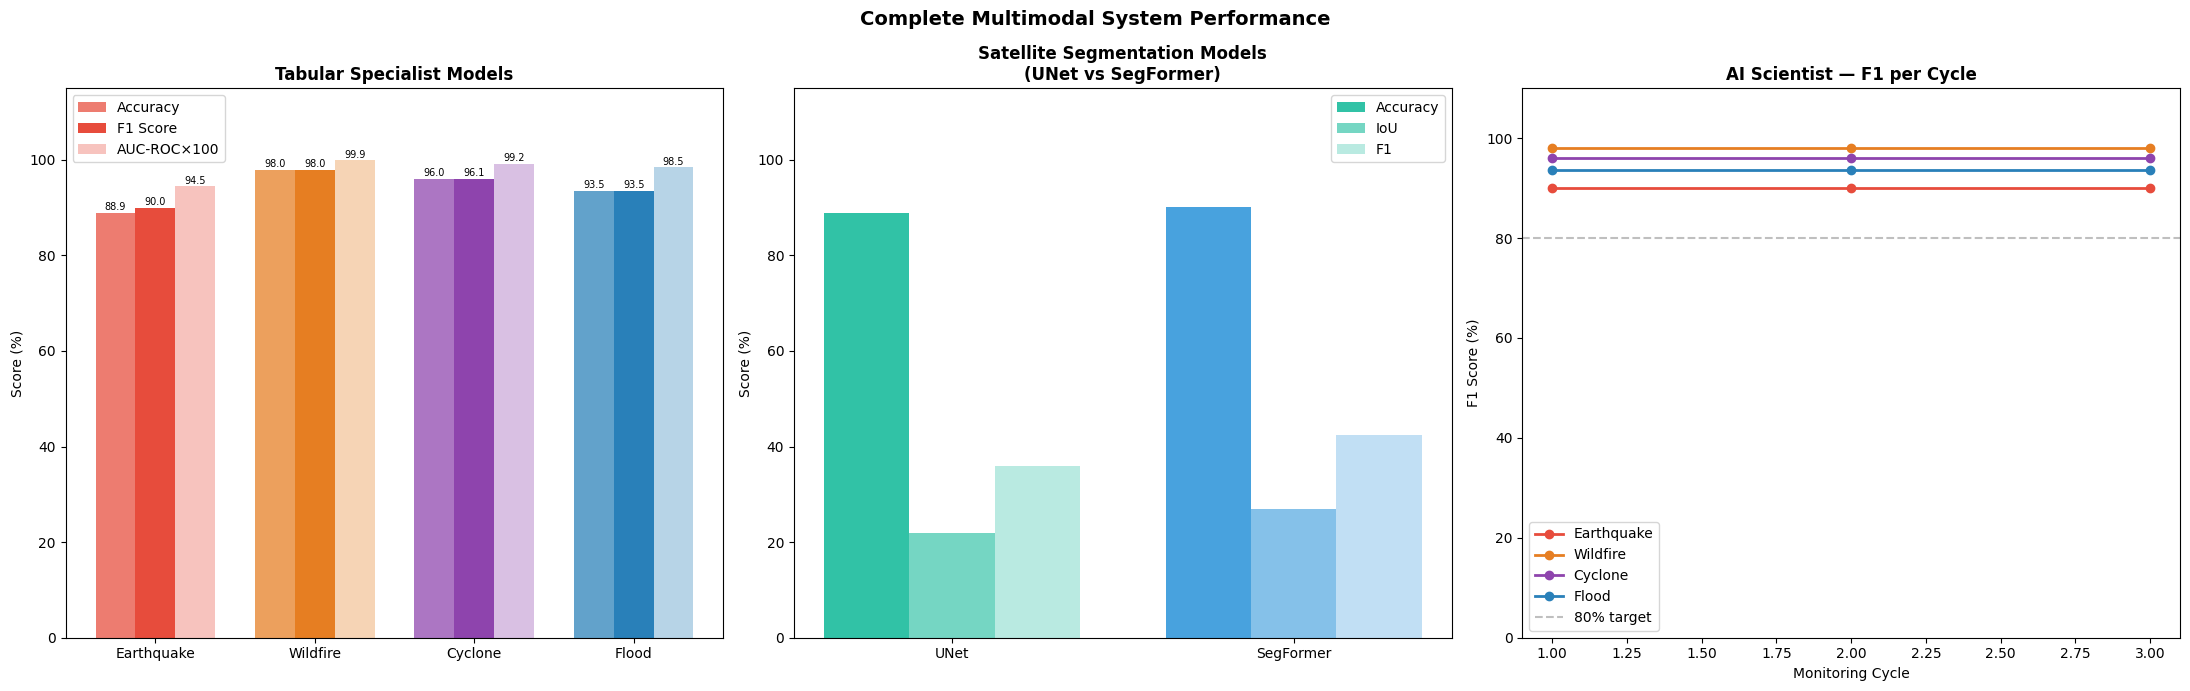


  COMPLETE SYSTEM PERFORMANCE REPORT

  TABULAR SPECIALIST MODELS:
  Model            Accuracy   F1 Score    AUC-ROC
  ------------------------------------------------
  Earthquake        88.92%    89.99%    0.9451
  Wildfire          97.97%    97.97%    0.9990
  Cyclone           96.01%    96.08%    0.9920
  Flood             93.52%    93.53%    0.9847

  SATELLITE SEGMENTATION MODELS:
  Model            Accuracy        IoU         F1
  ---------------------------------------------
  UNet              88.88%    21.90%    35.93%
  SegFormer         90.15%    26.86%    42.34%

  Best segmentation model : SegFormer
  AI Scientist cycles     : 3
  Auto-retrains triggered : 0
  Results saved to        : /content/drive/MyDrive/DisasterAI_Final/results/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Complete Multimodal System Performance', fontsize=14, fontweight='bold')
colors=['#e74c3c','#e67e22','#8e44ad','#2980b9']

# ── Plot 1: Tabular specialist scores (Case-Insensitive Fix) ────────
ax1 = axes[0]
# Normalize keys to lowercase to ensure they match our hardcoded list
available_specs = {k.lower(): v for k, v in SPECIALIST_SCORES.items() if v}
names = ['earthquake', 'wildfire', 'cyclone', 'flood']

accs = [available_specs.get(k, {}).get('accuracy', 0) * 100 for k in names]
f1s  = [available_specs.get(k, {}).get('f1', 0) * 100 for k in names]
aucs = [available_specs.get(k, {}).get('auc_roc', 0) * 100 for k in names]

x = np.arange(len(names)); w = 0.25
b1 = ax1.bar(x - w, accs, w, label='Accuracy', color=[c + 'bb' for c in colors])
b2 = ax1.bar(x, f1s, w, label='F1 Score', color=colors)
b3 = ax1.bar(x + w, aucs, w, label='AUC-ROC×100', color=[c + '55' for c in colors])

ax1.set_xticks(x); ax1.set_xticklabels([n.capitalize() for n in names])
ax1.set_ylabel('Score (%)'); ax1.set_title('Tabular Specialist Models', fontweight='bold')
ax1.legend(); ax1.set_ylim(0, 115)

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    if h > 0: ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h:.1f}', ha='center', fontsize=7)

# ── Plot 2: Satellite segmentation models ──────────────────────────
ax2 = axes[1]
seg_names = ['UNet', 'SegFormer']
seg_acc = [unet_metrics['accuracy'] * 100, segformer_metrics['accuracy'] * 100]
seg_iou = [unet_metrics['iou'] * 100, segformer_metrics['iou'] * 100]
seg_f1  = [unet_metrics['f1'] * 100, segformer_metrics['f1'] * 100]
x2 = np.arange(2)
ax2.bar(x2 - 0.25, seg_acc, 0.25, label='Accuracy', color=['#1abc9c', '#3498db'], alpha=0.9)
ax2.bar(x2, seg_iou, 0.25, label='IoU', color=['#1abc9c', '#3498db'], alpha=0.6)
ax2.bar(x2 + 0.25, seg_f1, 0.25, label='F1', color=['#1abc9c', '#3498db'], alpha=0.3)
ax2.set_xticks(x2); ax2.set_xticklabels(seg_names)
ax2.set_ylabel('Score (%)'); ax2.set_ylim(0, 115)
ax2.set_title('Satellite Segmentation Models\n(UNet vs SegFormer)', fontweight='bold')
ax2.legend()

# ── Plot 3: AI Scientist monitoring (X-Axis Fix) ───────────────────
ax3 = axes[2]
if 'scientist_log' in locals() and scientist_log:
    for d, c in zip(['earthquake', 'wildfire', 'cyclone', 'flood'], colors):
        # Using .get() for 'cycle' prevents the KeyError
        cycles = [l.get('cycle', i+1) for i, l in enumerate(scientist_log)]
        vals = [l['current_f1'].get(d, 0) * 100 for l in scientist_log]
        if any(v > 0 for v in vals):
            ax3.plot(cycles, vals, 'o-', label=d.capitalize(), color=c, linewidth=2, markersize=6)

ax3.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% target')
ax3.set_xlabel('Monitoring Cycle'); ax3.set_ylabel('F1 Score (%)')
ax3.set_title('AI Scientist — F1 per Cycle', fontweight='bold')
ax3.legend(); ax3.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(f'{RES_DIR}/final_multimodal_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Text Report (Variable Sync Fix) ────────────────────────────────
print("\n" + "=" * 65)
print("  COMPLETE SYSTEM PERFORMANCE REPORT")
print("=" * 65)

# Calculate total retrains from your new log_entries
total_retrains = sum(1 for cycle in log_entries for s in cycle['specialists'].values() if "RETRAINED" in s['action_taken'])

print(f"\n  TABULAR SPECIALIST MODELS:")
print(f"  {'Model':<14} {'Accuracy':>10} {'F1 Score':>10} {'AUC-ROC':>10}")
print("  " + "-" * 48)
for name in names:
    scores = available_specs.get(name, {})
    if scores:
        print(f"  {name.capitalize():<14}{scores.get('accuracy', 0) * 100:>9.2f}%"
              f"{scores.get('f1', 0) * 100:>9.2f}%{scores.get('auc_roc', 0):>10.4f}")

print(f"\n  SATELLITE SEGMENTATION MODELS:")
print(f"  {'Model':<14} {'Accuracy':>10} {'IoU':>10} {'F1':>10}")
print("  " + "-" * 45)
for mname, mmet in [('UNet', unet_metrics), ('SegFormer', segformer_metrics)]:
    print(f"  {mname:<14}{mmet['accuracy'] * 100:>9.2f}%{mmet['iou'] * 100:>9.2f}%"
          f"{mmet['f1'] * 100:>9.2f}%")

print(f"\n  Best segmentation model : {'UNet' if unet_metrics['iou'] >= segformer_metrics['iou'] else 'SegFormer'}")
print(f"  AI Scientist cycles     : {len(log_entries)}")
print(f"  Auto-retrains triggered : {total_retrains}")
print(f"  Results saved to        : {RES_DIR}/")
print("=" * 65)